In [15]:
# #@title
# !pip install \
#     beautifulsoup4==4.14.3 \
#     certifi==2026.4.22 \
#     charset-normalizer==3.4.7 \
#     contourpy==1.3.3 \
#     cycler==0.12.1 \
#     filelock==3.29.0 \
#     fonttools==4.62.1 \
#     gdown==6.0.0 \
#     idna==3.15 \
#     kiwisolver==1.5.0 \
#     matplotlib==3.10.9 \
#     numpy==2.4.4 \
#     packaging==26.2 \
#     pandas==3.0.3 \
#     patsy==1.0.2 \
#     pillow==12.2.0 \
#     pyparsing==3.3.2 \
#     PySocks==1.7.1 \
#     python-dateutil==2.9.0.post0 \
#     requests==2.34.0 \
#     scipy==1.17.1 \
#     seaborn==0.13.2 \
#     six==1.17.0 \
#     soupsieve==2.8.3 \
#     statsmodels==0.14.6 \
#     tqdm==4.67.3 \
#     typing_extensions==4.15.0 \
#     urllib3==2.7.0

# import gdown
# url     = "https://drive.google.com/file/d/19M6zJQ6vb28XnXS-YAYb_w4jC2SyIw4-/view?usp=sharing"
# output  = "results.csv"
# gdown.download(url=url, output=output, quiet=False)

In [16]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
DATA_PATH = "results.csv"
TIMEOUT = 1200  # seconds
OUT_DIR = Path("plots")
OUT_DIR.mkdir(exist_ok=True)

SOLVER_ORDER = ["chuffed", "gecode", "cp-sat", "coin-bc", "gurobi"]
PARADIGM_COLOR = {"cp": "#4CAF50", "ilp": "#FF7043"}
SOLVER_PALETTE = {
    "chuffed": "#4db6ac",
    "gecode": "#ff8a65",
    "cp-sat": "#7986cb",
    "coin-bc": "#f06292",
    "gurobi": "#aed581",
}
SIZE_ORDER = ["j30", "j60", "j90", "j120"]

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 300})

In [17]:
# ── Load & clean ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)

# Normalise column names (strip whitespace)
df.columns = df.columns.str.strip()

# Derived flags
df["solved"] = df["status"] == "ok"
df["timed_out"] = df["elapsed_seconds"] >= TIMEOUT - 1  # within 1 s of timeout

# Ensure categorical ordering
df["problem_size"] = pd.Categorical(
    df["problem_size"], categories=SIZE_ORDER, ordered=True
)
df["solver"] = pd.Categorical(df["solver"], categories=SOLVER_ORDER, ordered=True)

# Best makespan per instance across ALL solvers (used as reference for quality plots)
best_per_instance = (
    df[df["solved"]]
    .groupby(["problem_size", "instance_name"])["makespan"]
    .min()
    .rename("best_makespan")
)
df = df.join(best_per_instance, on=["problem_size", "instance_name"])
df["optimality_gap_pct"] = (
    (df["makespan"] - df["best_makespan"]) / df["best_makespan"] * 100
)

df.head()

,timestamp,problem_size,instance_name,run_number,runs_per_instance,paradigm,solver,model,started_at,finished_at,...,avg_ram_mb,max_ram_mb,cpu_percent,makespan,status,error,solved,timed_out,best_makespan,optimality_gap_pct
0,2026-05-14-20:21:15,j30,j3013_8,aion-0003,1,cp,chuffed,rcpsp_cp.mzn,2026-05-14T22:46:30,2026-05-14T23:06:30,...,184.14,267.80,99.6,106.0,ok,NaN,True,True,106.0,0.0
1,2026-05-14-20:21:15,j30,j3013_8,aion-0008,1,cp,chuffed,rcpsp_cp.mzn,2026-05-14T22:46:31,2026-05-14T23:06:31,...,183.05,262.98,99.6,106.0,ok,NaN,True,True,106.0,0.0
2,2026-05-14-20:21:19,j30,j3013_8,aion-0012,1,cp,chuffed,rcpsp_cp.mzn,2026-05-14T22:46:33,2026-05-14T23:06:33,...,184.39,268.10,99.7,106.0,ok,NaN,True,True,106.0,0.0
3,2026-05-14-20:21:19,j30,j3013_8,aion-0017,1,cp,chuffed,rcpsp_cp.mzn,2026-05-14T22:46:33,2026-05-14T23:06:33,...,183.97,267.53,99.6,106.0,ok,NaN,True,True,106.0,0.0
4,2026-05-14-20:21:19,j30,j3013_8,aion-0021,1,cp,chuffed,rcpsp_cp.mzn,2026-05-14T22:46:34,2026-05-14T23:06:34,...,184.51,268.30,99.7,106.0,ok,NaN,True,True,106.0,0.0


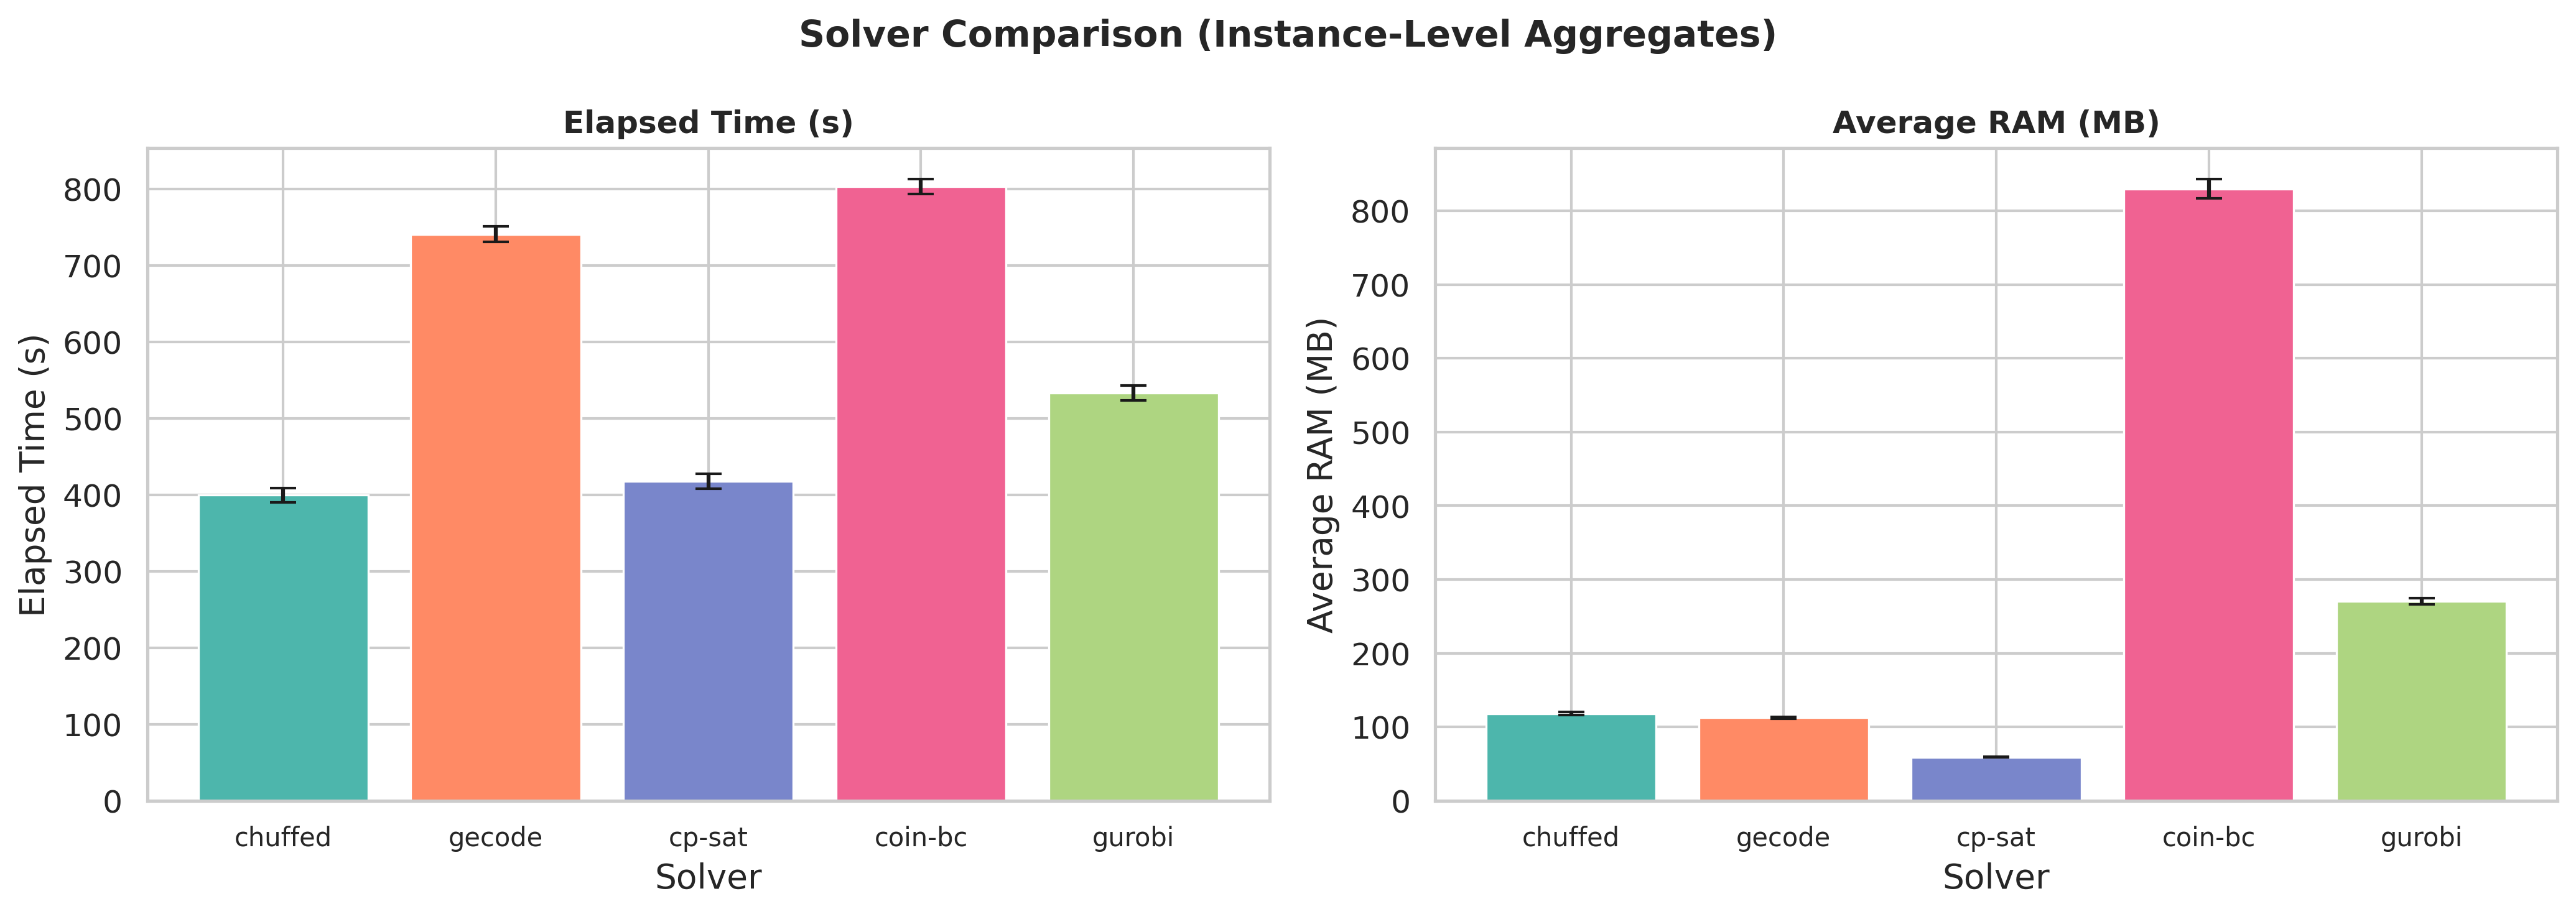

Plot 0 done.


In [18]:
# =============================================================================
# PLOT 0 — Solver Bar Comparison  (original, kept as-is — easy to read)
# =============================================================================


def plot_solver_bar_comparison(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    agg = (
        df.groupby("solver")
        .agg(
            mean_time=("elapsed_seconds", "mean"),
            sem_time=("elapsed_seconds", "sem"),
            mean_ram=("avg_ram_mb", "mean"),
            sem_ram=("avg_ram_mb", "sem"),
        )
        .reindex(SOLVER_ORDER)
        .reset_index()
    )

    for ax, y_col, err_col, ylabel, title in [
        (axes[0], "mean_time", "sem_time", "Elapsed Time (s)", "Elapsed Time (s)"),
        (axes[1], "mean_ram", "sem_ram", "Average RAM (MB)", "Average RAM (MB)"),
    ]:
        ax.bar(
            agg["solver"],
            agg[y_col],
            color=[SOLVER_PALETTE[s] for s in agg["solver"]],
            edgecolor="white",
            linewidth=0.8,
            yerr=1.96 * agg[err_col],
            capsize=5,
            error_kw={"linewidth": 1.5},
        )
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Solver")
        ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(agg)))
        ax.set_xticklabels(agg["solver"], fontsize=10)

    fig.suptitle(
        "Solver Comparison (Instance-Level Aggregates)", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / "00_solver_bar_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Plot 0 done.")


plot_solver_bar_comparison(df)

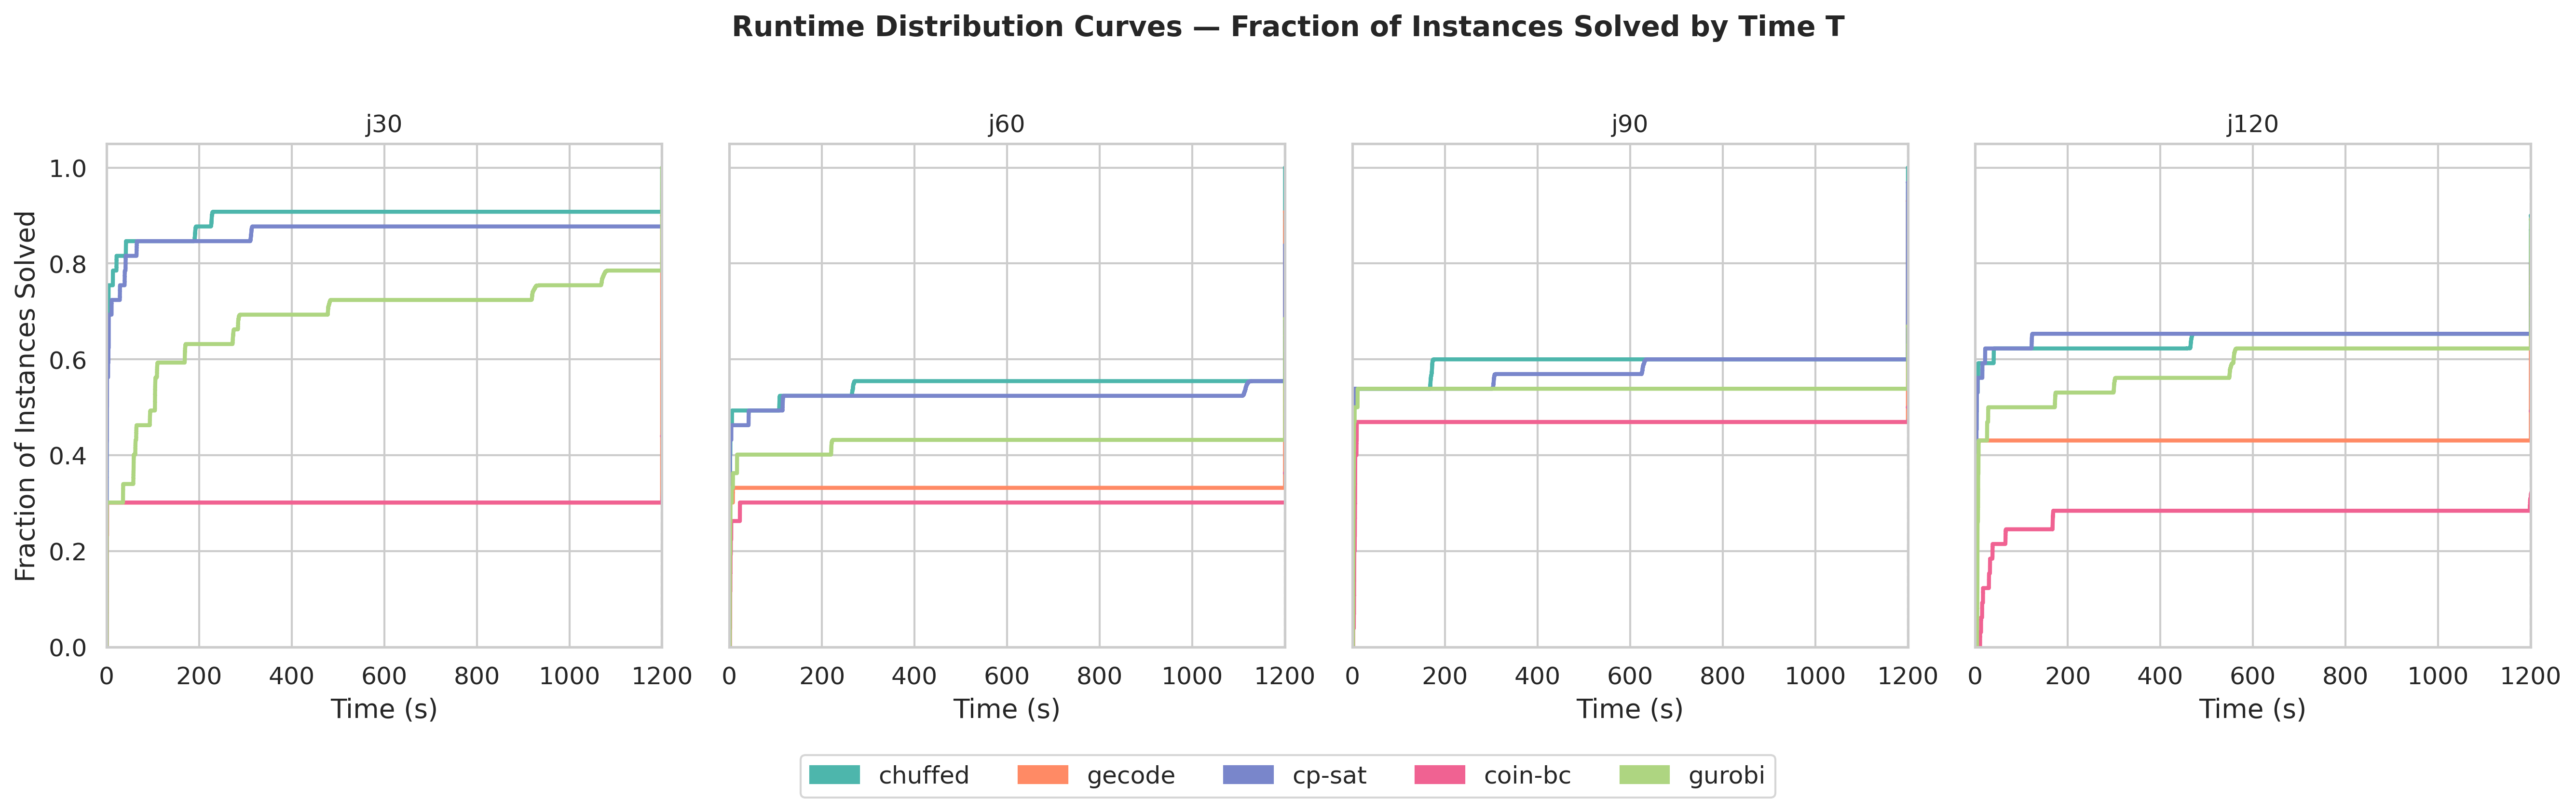

In [19]:
# =============================================================================
# PLOT 1 — Runtime Distribution Curves  (the most important plot)
# =============================================================================
# For each solver, what fraction of instances are solved within T seconds?
# This is the standard solver competition plot (PAR-2 style but continuous).
# Timeouts are correctly handled as "not solved" rather than contributing to the mean.
# =============================================================================


def plot_runtime_distributions(df, timeout=TIMEOUT):
    fig, axes = plt.subplots(1, len(SIZE_ORDER), figsize=(18, 5), sharey=True)
    fig.suptitle(
        "Runtime Distribution Curves — Fraction of Instances Solved by Time T",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )

    for ax, size in zip(axes, SIZE_ORDER):
        sub = df[df["problem_size"] == size]
        total = sub.groupby("solver")["instance_name"].nunique()

        for solver in SOLVER_ORDER:
            s = sub[sub["solver"] == solver].copy()
            if s.empty:
                continue
            n_total = len(s)
            solved = s[s["solved"]].sort_values("elapsed_seconds")
            if solved.empty:
                continue

            # Build step function: (time, cumulative fraction solved)
            times = [0] + list(solved["elapsed_seconds"]) + [timeout]
            fracs = (
                [0]
                + [i / n_total for i in range(1, len(solved) + 1)]
                + [len(solved) / n_total]
            )

            ax.step(
                times,
                fracs,
                where="post",
                color=SOLVER_PALETTE[solver],
                label=solver,
                linewidth=2,
            )

        ax.set_xlim(0, timeout)
        ax.set_ylim(0, 1.05)
        ax.set_title(size, fontsize=12)
        ax.set_xlabel("Time (s)")
        ax.axvline(timeout, color="gray", linestyle="--", alpha=0.5, linewidth=1)

    axes[0].set_ylabel("Fraction of Instances Solved")

    handles = [mpatches.Patch(color=SOLVER_PALETTE[s], label=s) for s in SOLVER_ORDER]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=5,
        bbox_to_anchor=(0.5, -0.08),
        frameon=True,
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / "01_runtime_distributions.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_runtime_distributions(df)

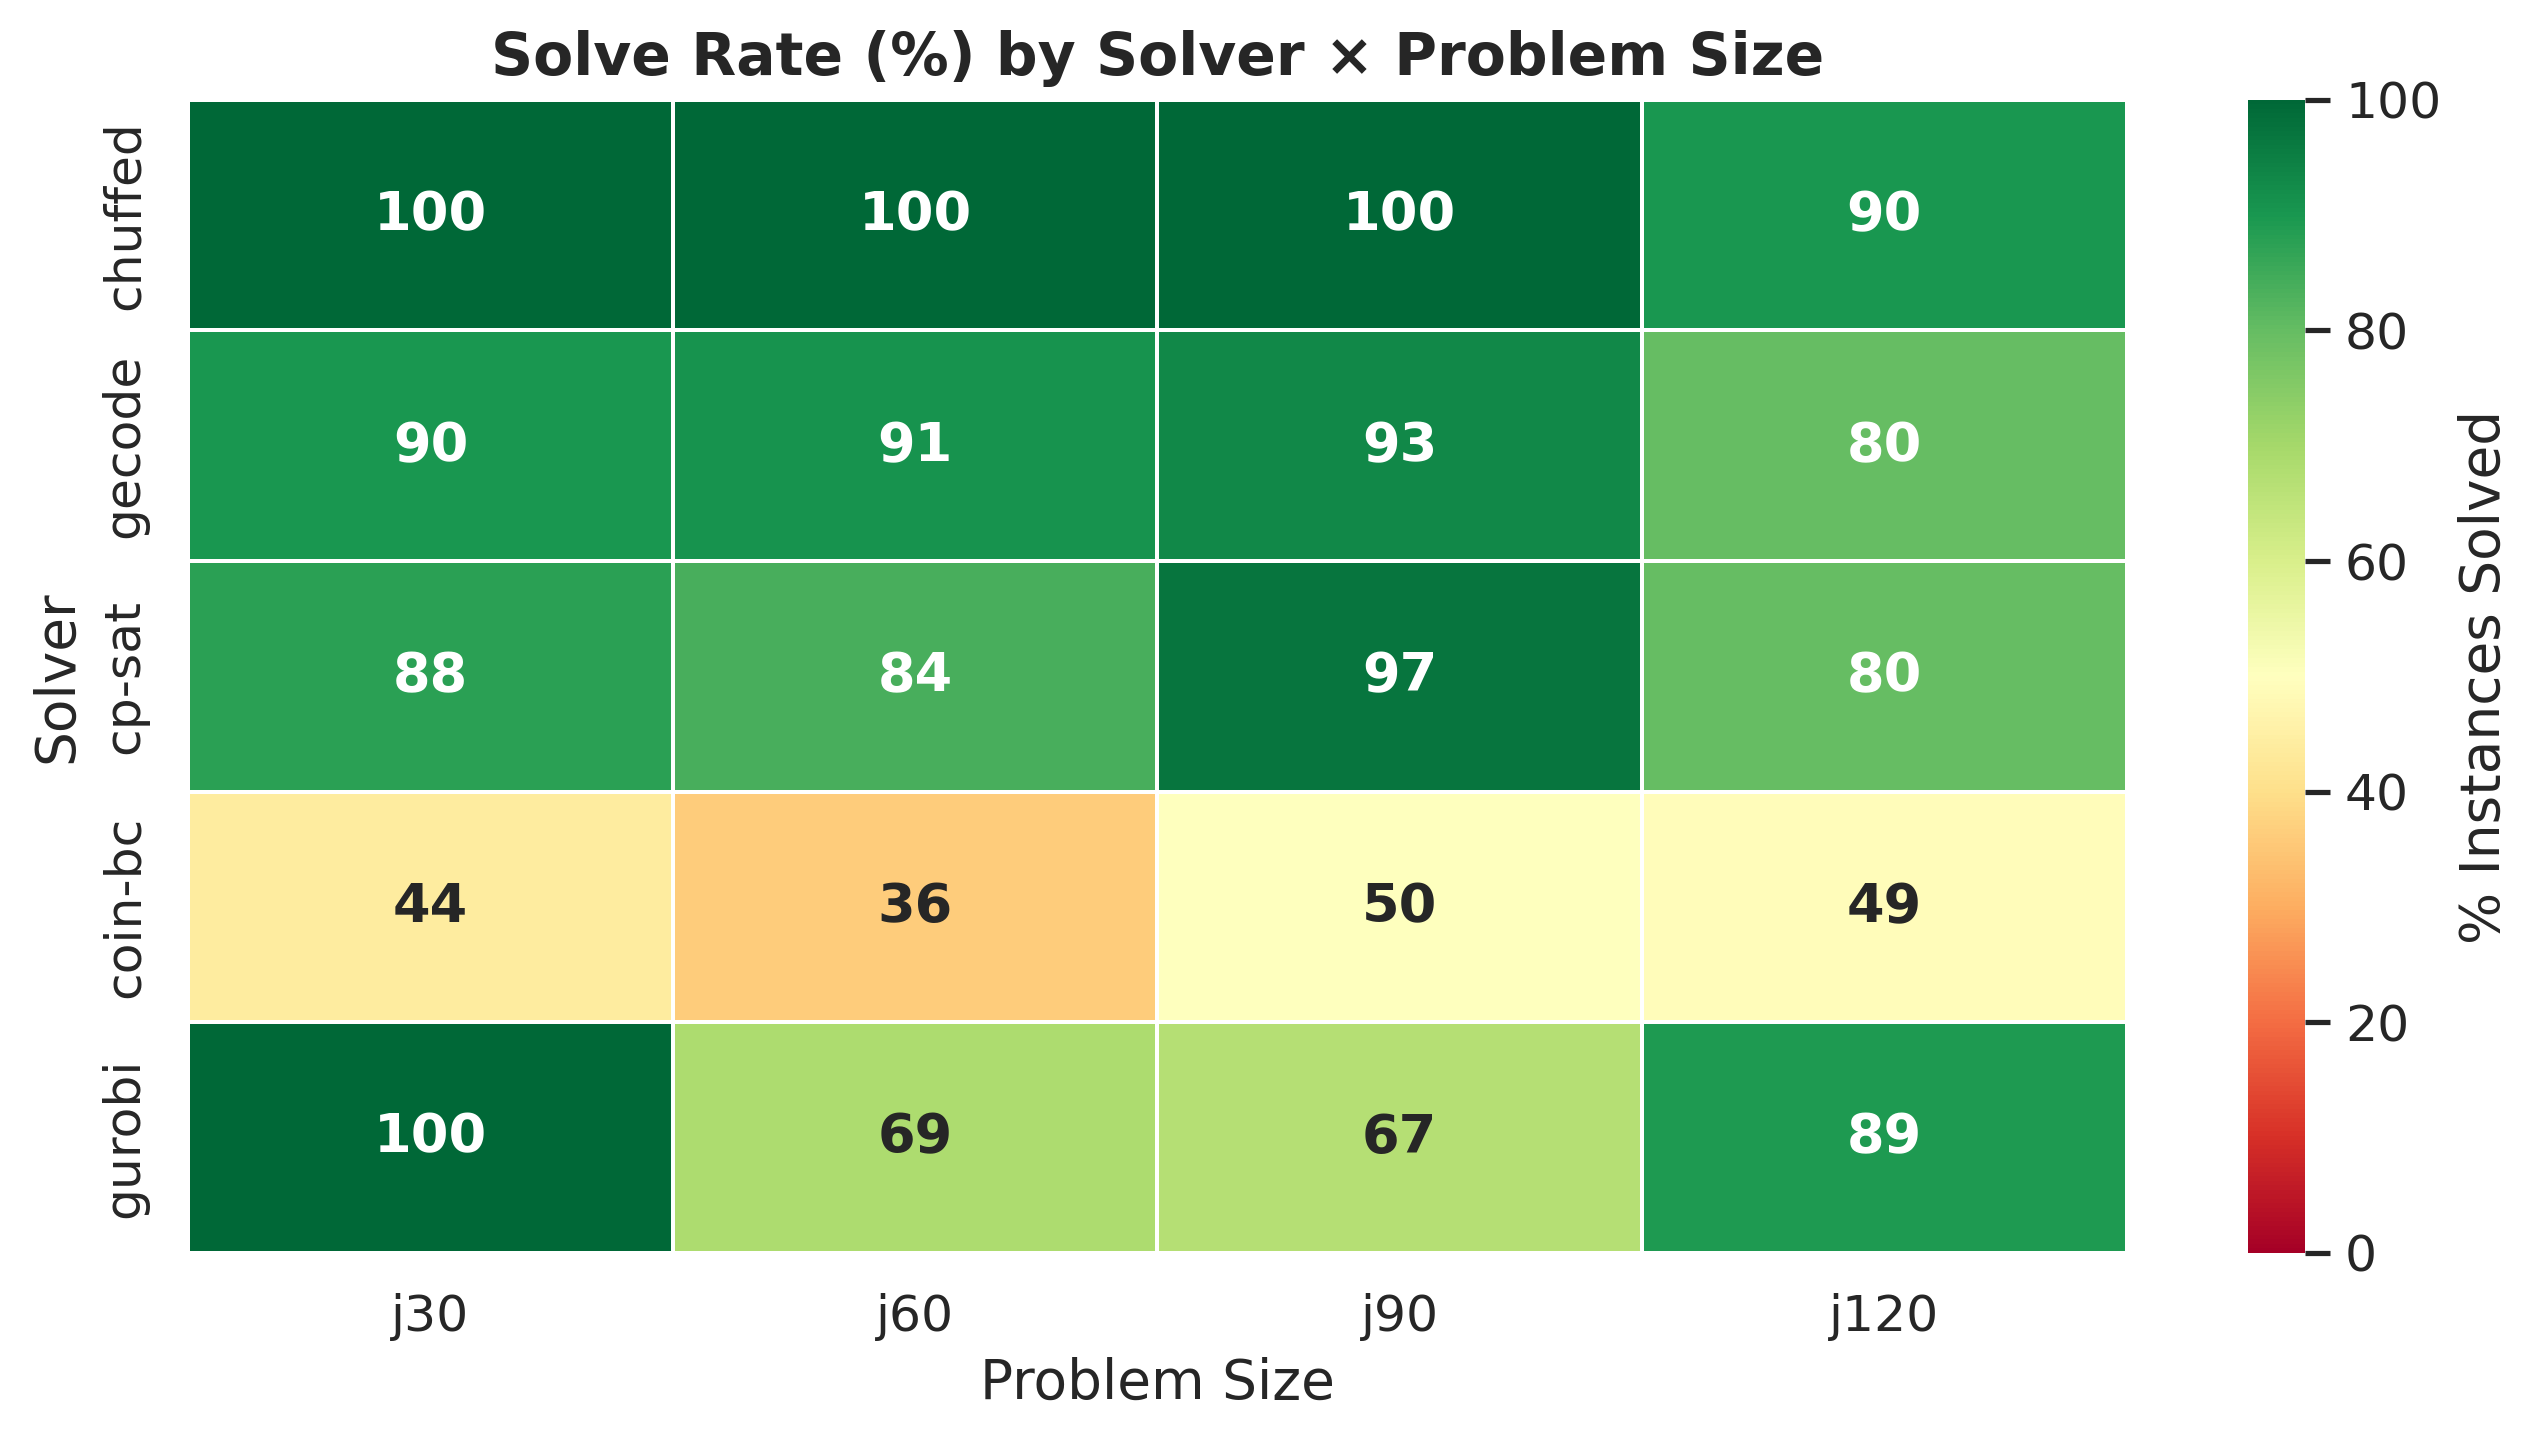

In [20]:
# =============================================================================
# PLOT 2 — Solve Rate Heatmap  (replaces the boxplots which were all at 1200s)
# =============================================================================
# % of instances solved before timeout, by solver × problem size.
# Much more honest than mean elapsed time.
# =============================================================================


def plot_solve_rate_heatmap(df):
    pivot = (
        df.groupby(["solver", "problem_size"])["solved"]
        .mean()
        .mul(100)
        .reset_index()
        .pivot(index="solver", columns="problem_size", values="solved")
        .reindex(index=SOLVER_ORDER, columns=SIZE_ORDER)
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0f",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 13, "weight": "bold"},
        cbar_kws={"label": "% Instances Solved"},
    )
    ax.set_title(
        "Solve Rate (%) by Solver × Problem Size", fontsize=14, fontweight="bold"
    )
    ax.set_xlabel("Problem Size")
    ax.set_ylabel("Solver")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "02_solve_rate_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_solve_rate_heatmap(df)

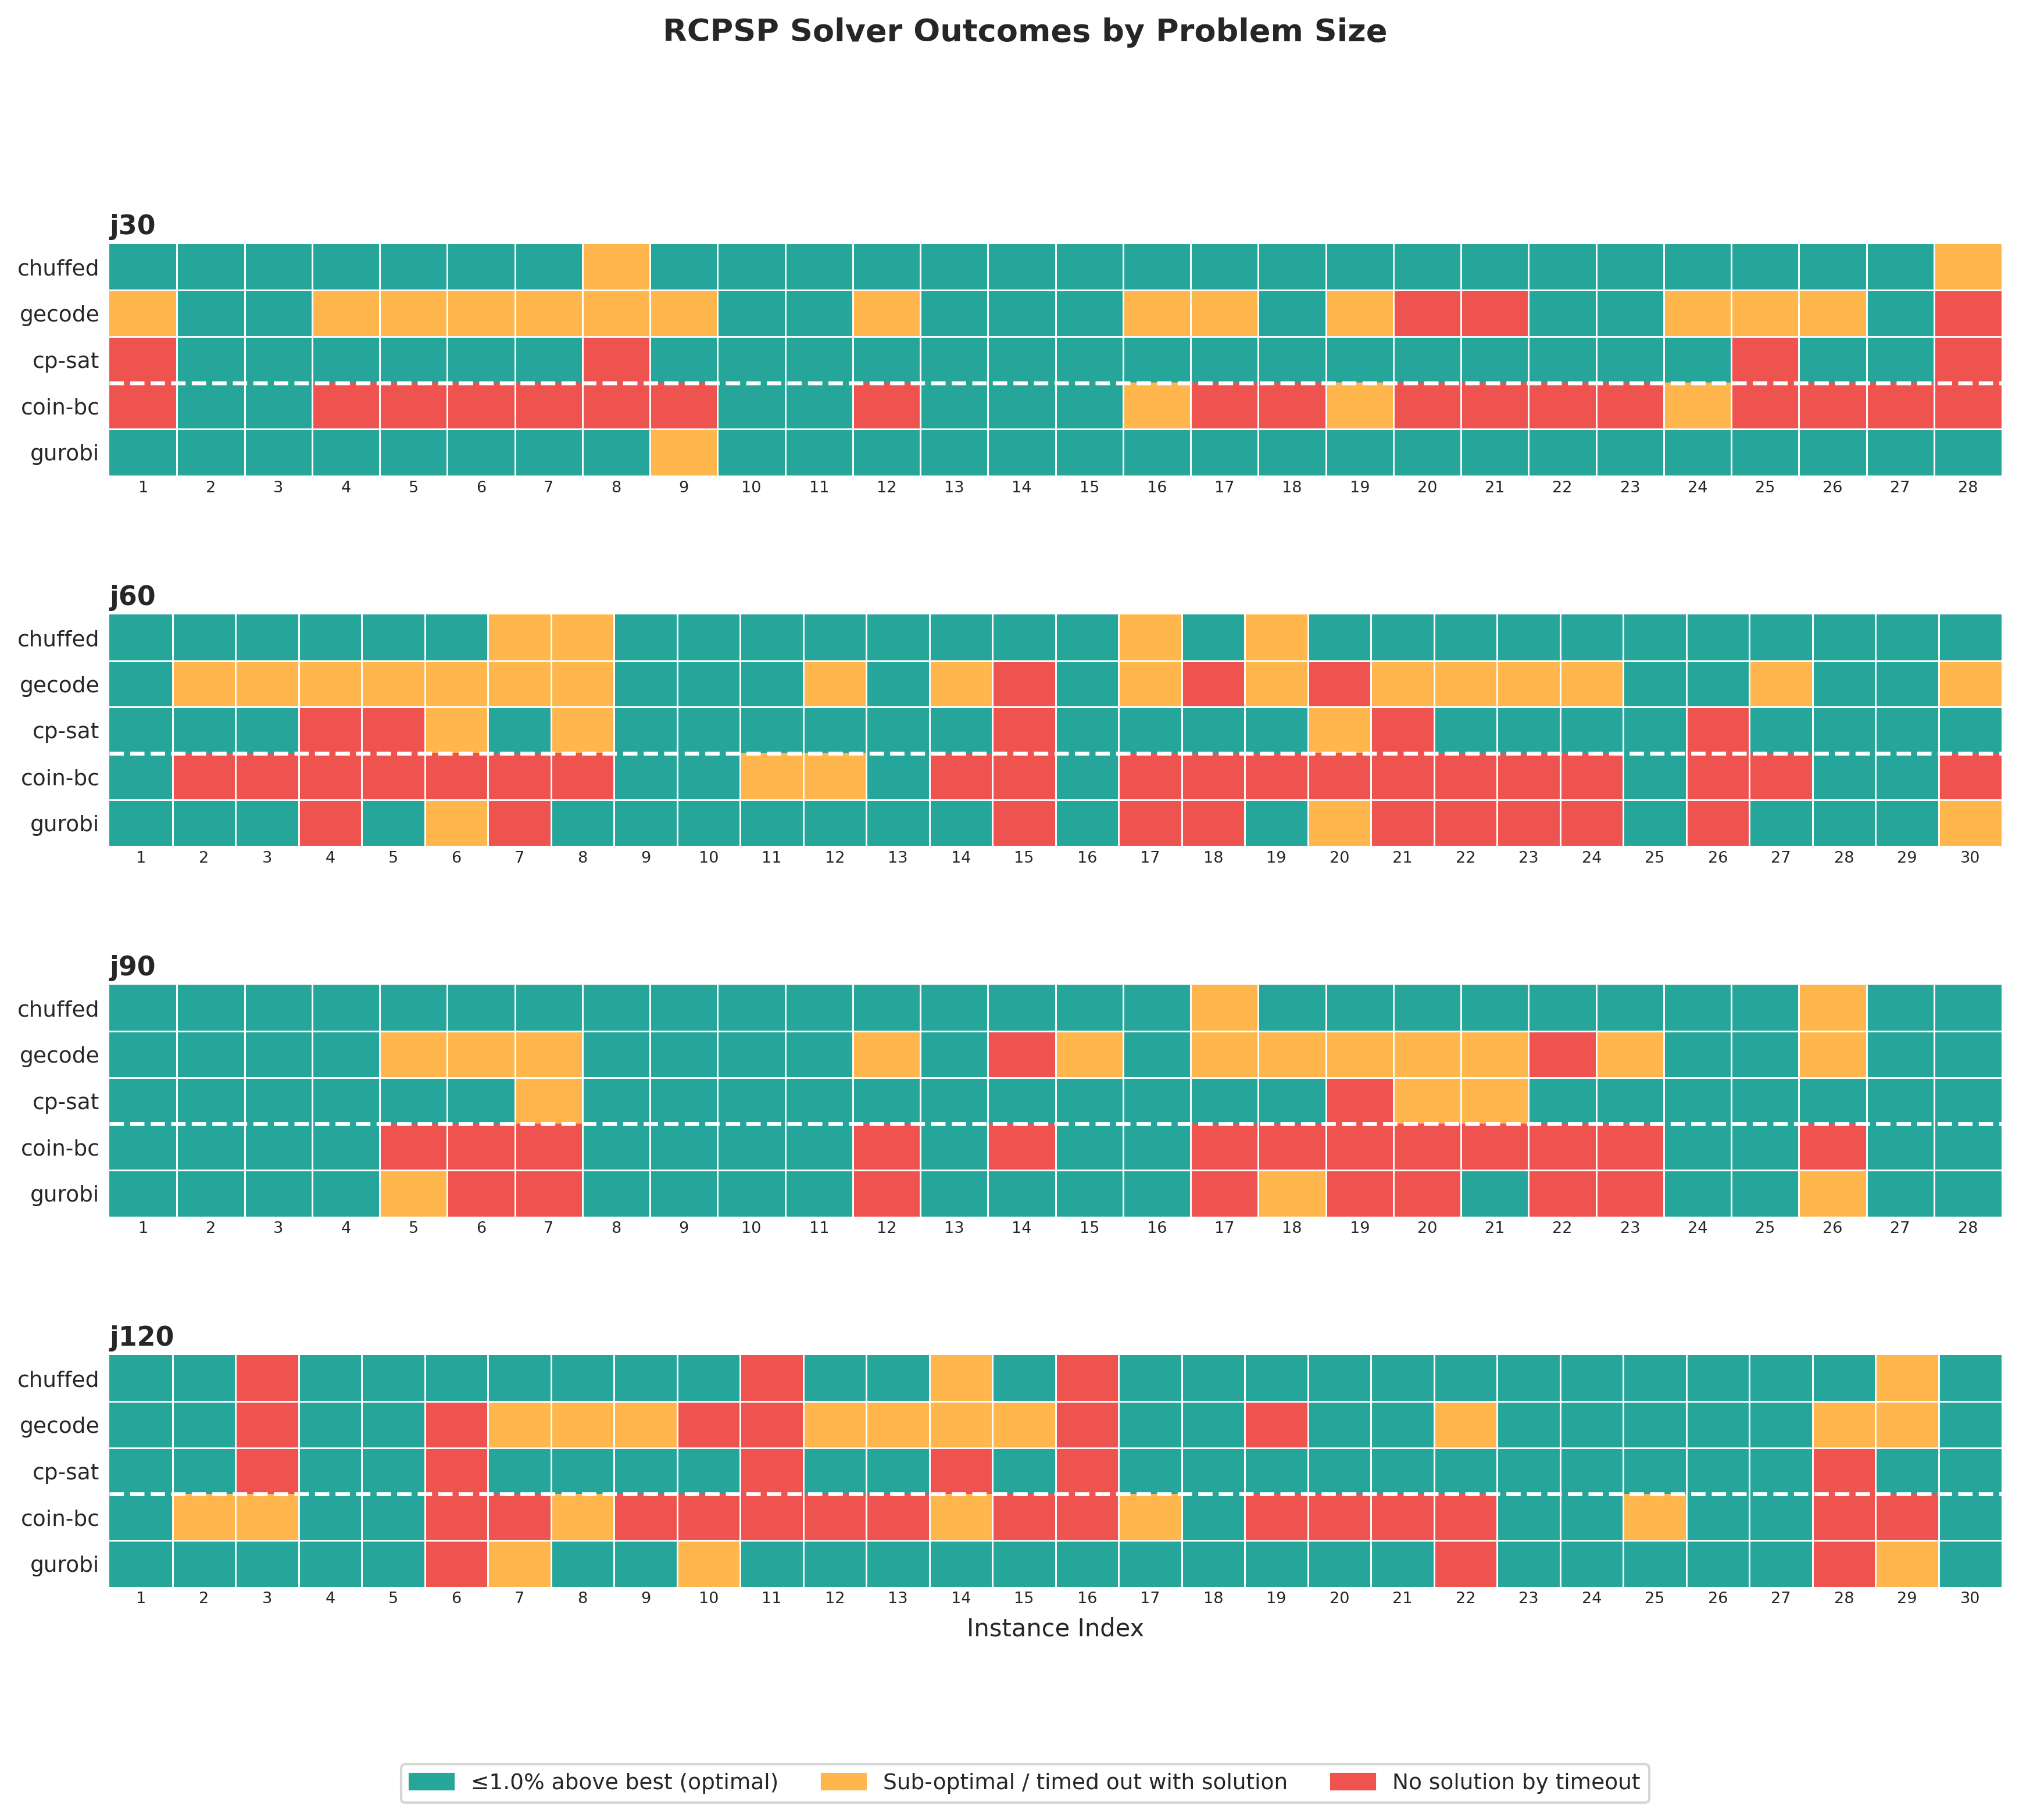

Plot 03 done.


In [21]:
# =============================================================================
# PLOT 3 — Outcome Matrix  (Patch 5: vertical separators, indices on every panel,
#                         clipped xlim to remove horizontal dead space)
# =============================================================================
def plot_outcome_matrix(df, gap_threshold_pct=1.0):
    import matplotlib.colors as mcolors

    CMAP_COLORS = (
        np.array(
            [
                [38, 166, 154],
                [255, 183, 77],
                [239, 83, 80],
            ]
        )
        / 255.0
    )
    OUTCOME_MAP = {"optimal": 0, "non_optimal": 1, "no_solution": 2}

    cmap = mcolors.ListedColormap(CMAP_COLORS)
    norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    df = df.copy()
    conditions = [
        df["solved"] & (df["optimality_gap_pct"].fillna(999) <= gap_threshold_pct),
        df["solved"] & (df["optimality_gap_pct"].fillna(999) > gap_threshold_pct),
    ]
    df["outcome"] = np.select(
        conditions, ["optimal", "non_optimal"], default="no_solution"
    )
    df["outcome_int"] = df["outcome"].map(OUTCOME_MAP)

    CP_ILP_SPLIT = 2.5  # between cp-sat (row 2) and coin-bc (row 3)

    fig, axes = plt.subplots(
        len(SIZE_ORDER), 1, figsize=(14, 10), gridspec_kw={"hspace": 0.6}
    )

    for ax, size in zip(axes, SIZE_ORDER):
        sub = df[df["problem_size"] == size]
        instances = sorted(sub["instance_name"].unique())
        inst_idx = {name: i for i, name in enumerate(instances)}
        n_inst = len(instances)
        n_solvers = len(SOLVER_ORDER)

        matrix = np.full((n_solvers, n_inst), -1.0)
        for si, solver in enumerate(SOLVER_ORDER):
            for _, row in sub[sub["solver"] == solver].iterrows():
                if row["instance_name"] in inst_idx:
                    matrix[si, inst_idx[row["instance_name"]]] = row["outcome_int"]

        ax.imshow(
            matrix, cmap=cmap, norm=norm, aspect="auto", interpolation="none", zorder=1
        )

        # ── exact xlim / ylim — eliminates all horizontal dead space ─────────
        ax.set_xlim(-0.5, n_inst - 0.5)
        ax.set_ylim(n_solvers - 0.5, -0.5)  # top-to-bottom order

        # ── vertical white lines between every instance column ────────────────
        for x in np.arange(0.5, n_inst - 0.5, 1):
            ax.axvline(x, color="white", linewidth=0.7, zorder=2)

        # ── horizontal white lines between every solver row ───────────────────
        for y in np.arange(0.5, n_solvers - 0.5, 1):
            if abs(y - CP_ILP_SPLIT) < 0.01:
                continue  # skip — drawn as dashed below
            ax.axhline(y, color="white", linewidth=0.7, zorder=2)

        # ── dashed CP / ILP separator ─────────────────────────────────────────
        ax.axhline(CP_ILP_SPLIT, color="white", linewidth=1.6, linestyle="--", zorder=3)

        # ── solver labels ─────────────────────────────────────────────────────
        ax.set_yticks(range(n_solvers))
        ax.set_yticklabels(SOLVER_ORDER, fontsize=9)
        ax.tick_params(axis="y", length=0, pad=4)

        # ── instance index on EVERY panel ─────────────────────────────────────
        ax.set_xticks(range(n_inst))
        ax.set_xticklabels(range(1, n_inst + 1), fontsize=6.5)
        ax.tick_params(axis="x", length=0, pad=2)
        if size == SIZE_ORDER[-1]:
            ax.set_xlabel("Instance Index", fontsize=10)

        # ── problem size title ────────────────────────────────────────────────
        ax.set_title(size, fontsize=11, fontweight="bold", loc="left", pad=4)

        ax.set_frame_on(False)
        ax.grid(False)

    patches = [
        mpatches.Patch(
            color=CMAP_COLORS[0], label=f"≤{gap_threshold_pct}% above best (optimal)"
        ),
        mpatches.Patch(
            color=CMAP_COLORS[1], label="Sub-optimal / timed out with solution"
        ),
        mpatches.Patch(color=CMAP_COLORS[2], label="No solution by timeout"),
    ]
    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=9,
        frameon=True,
    )

    fig.suptitle(
        "RCPSP Solver Outcomes by Problem Size", fontsize=13, fontweight="bold", y=1.01
    )

    plt.savefig(OUT_DIR / "03_outcome_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Plot 03 done.")


plot_outcome_matrix(df)

/tmp/ipykernel_77313/2287518090.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


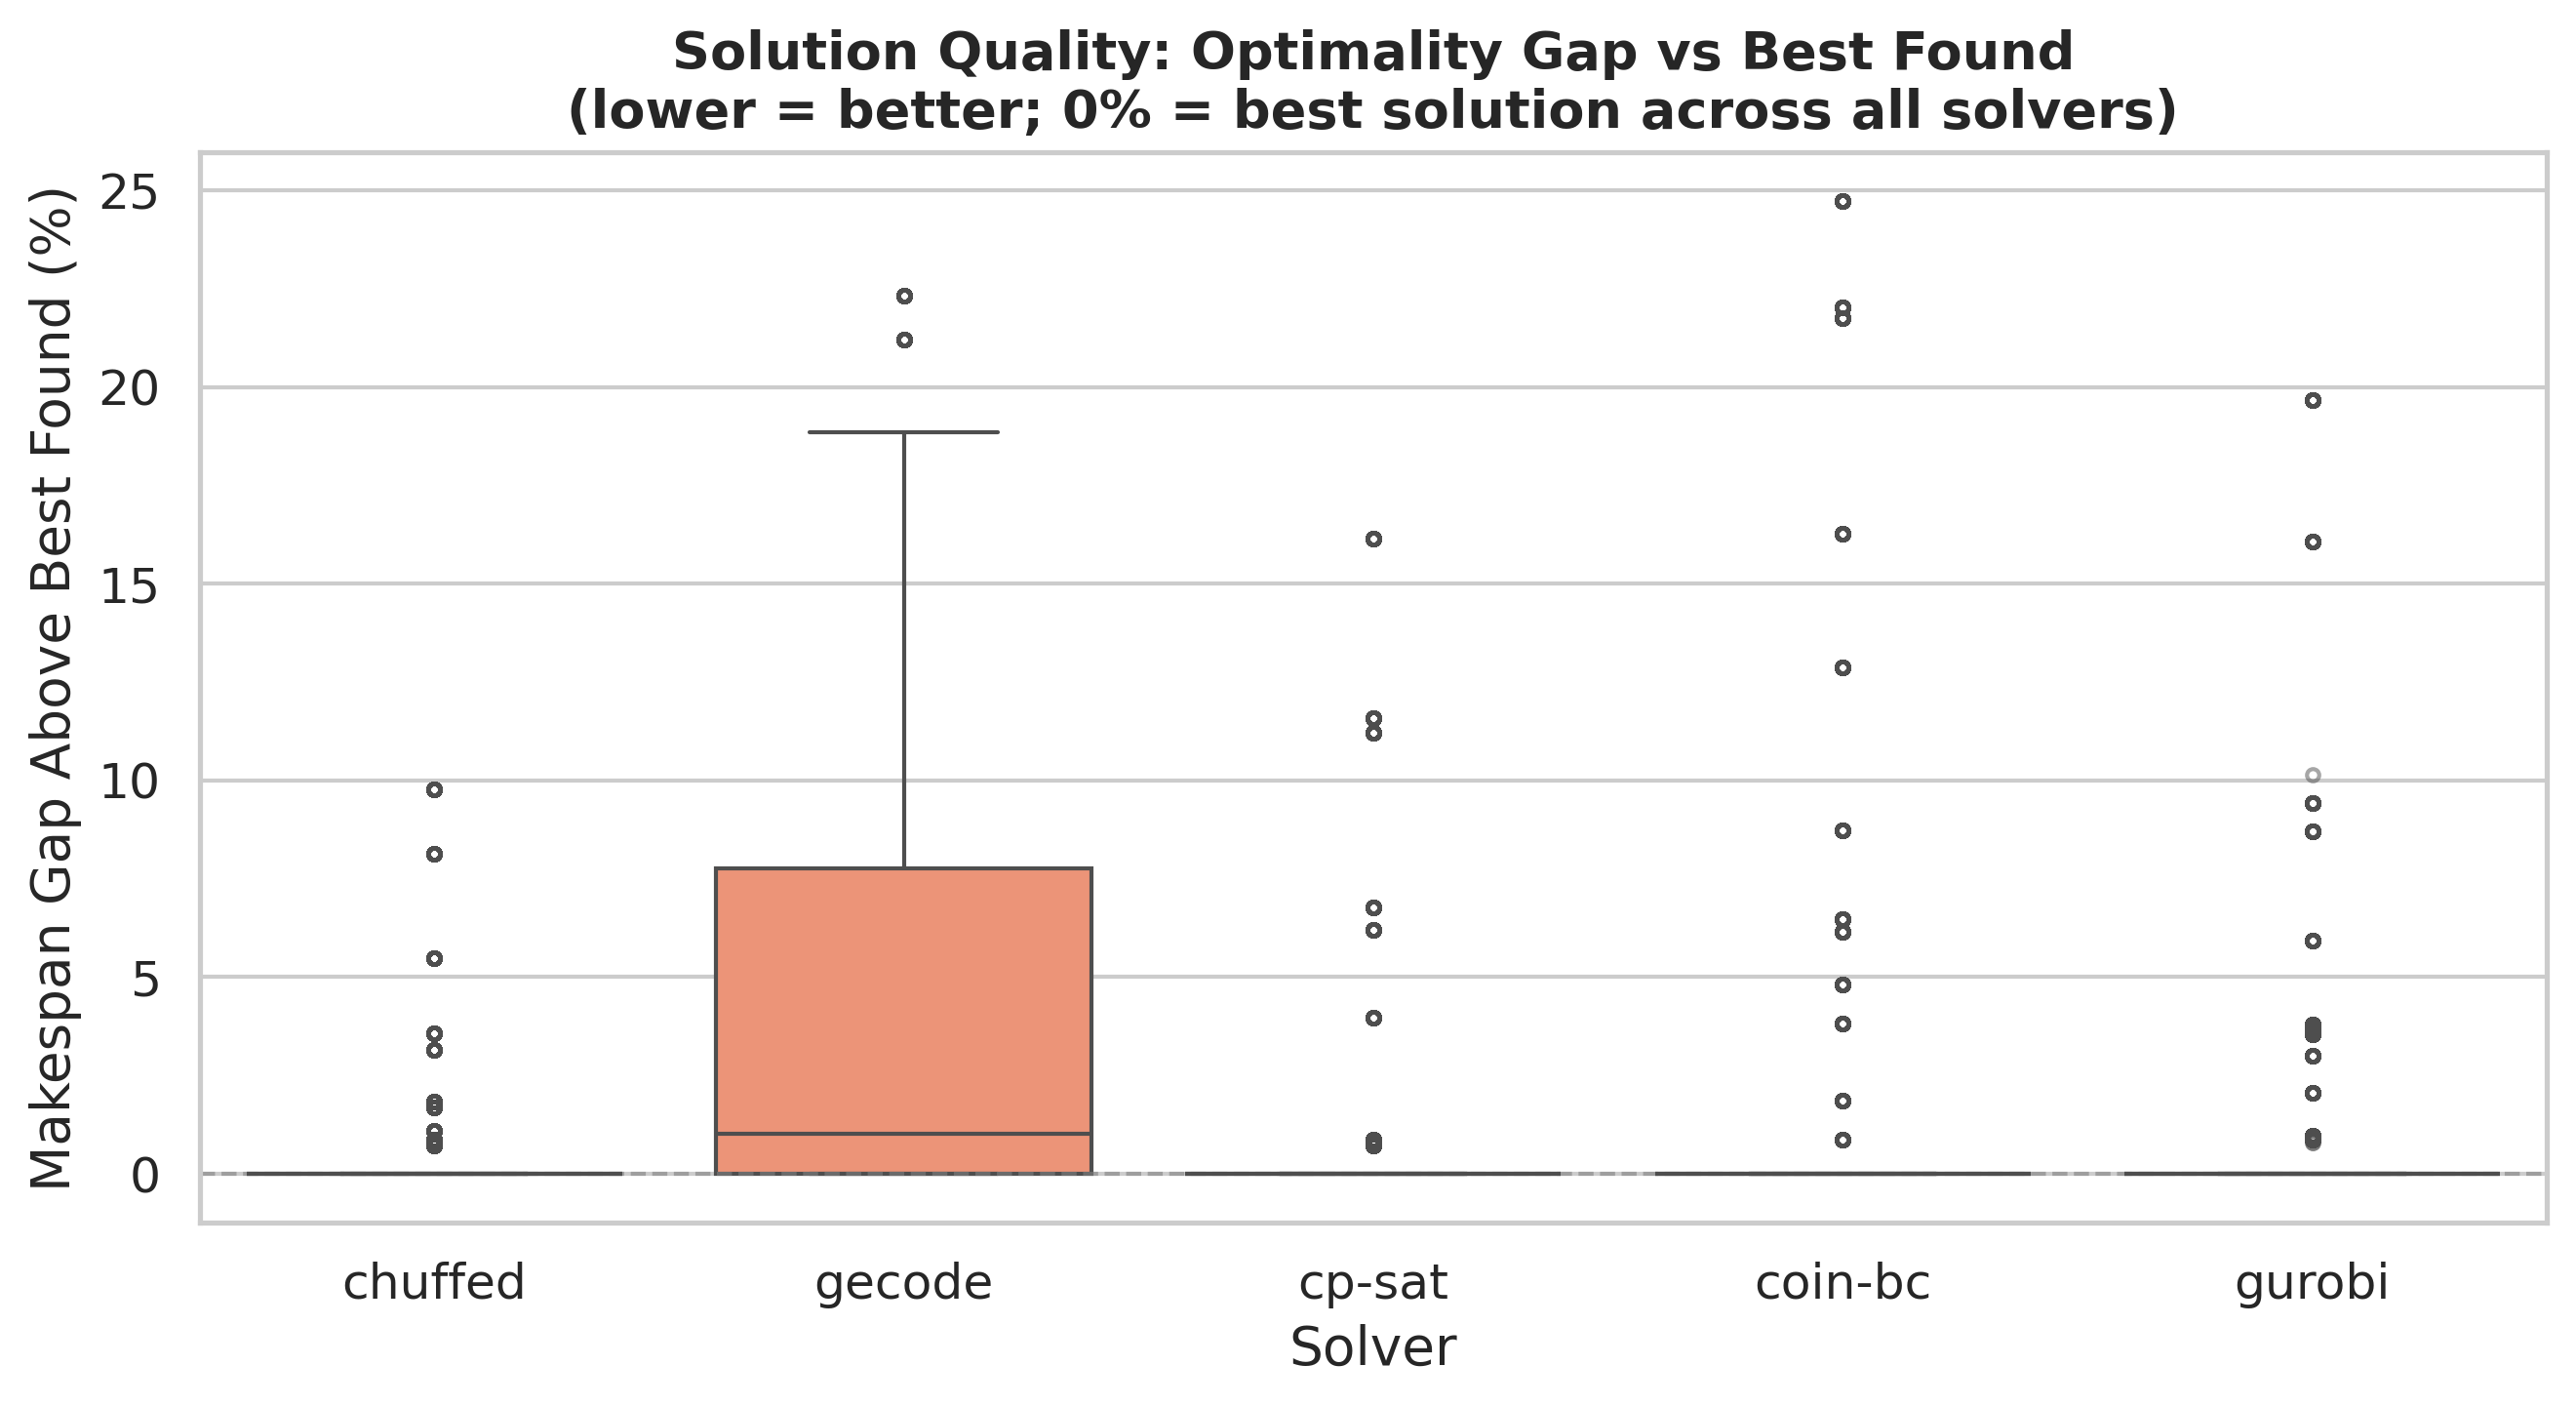

Plot 04a done.


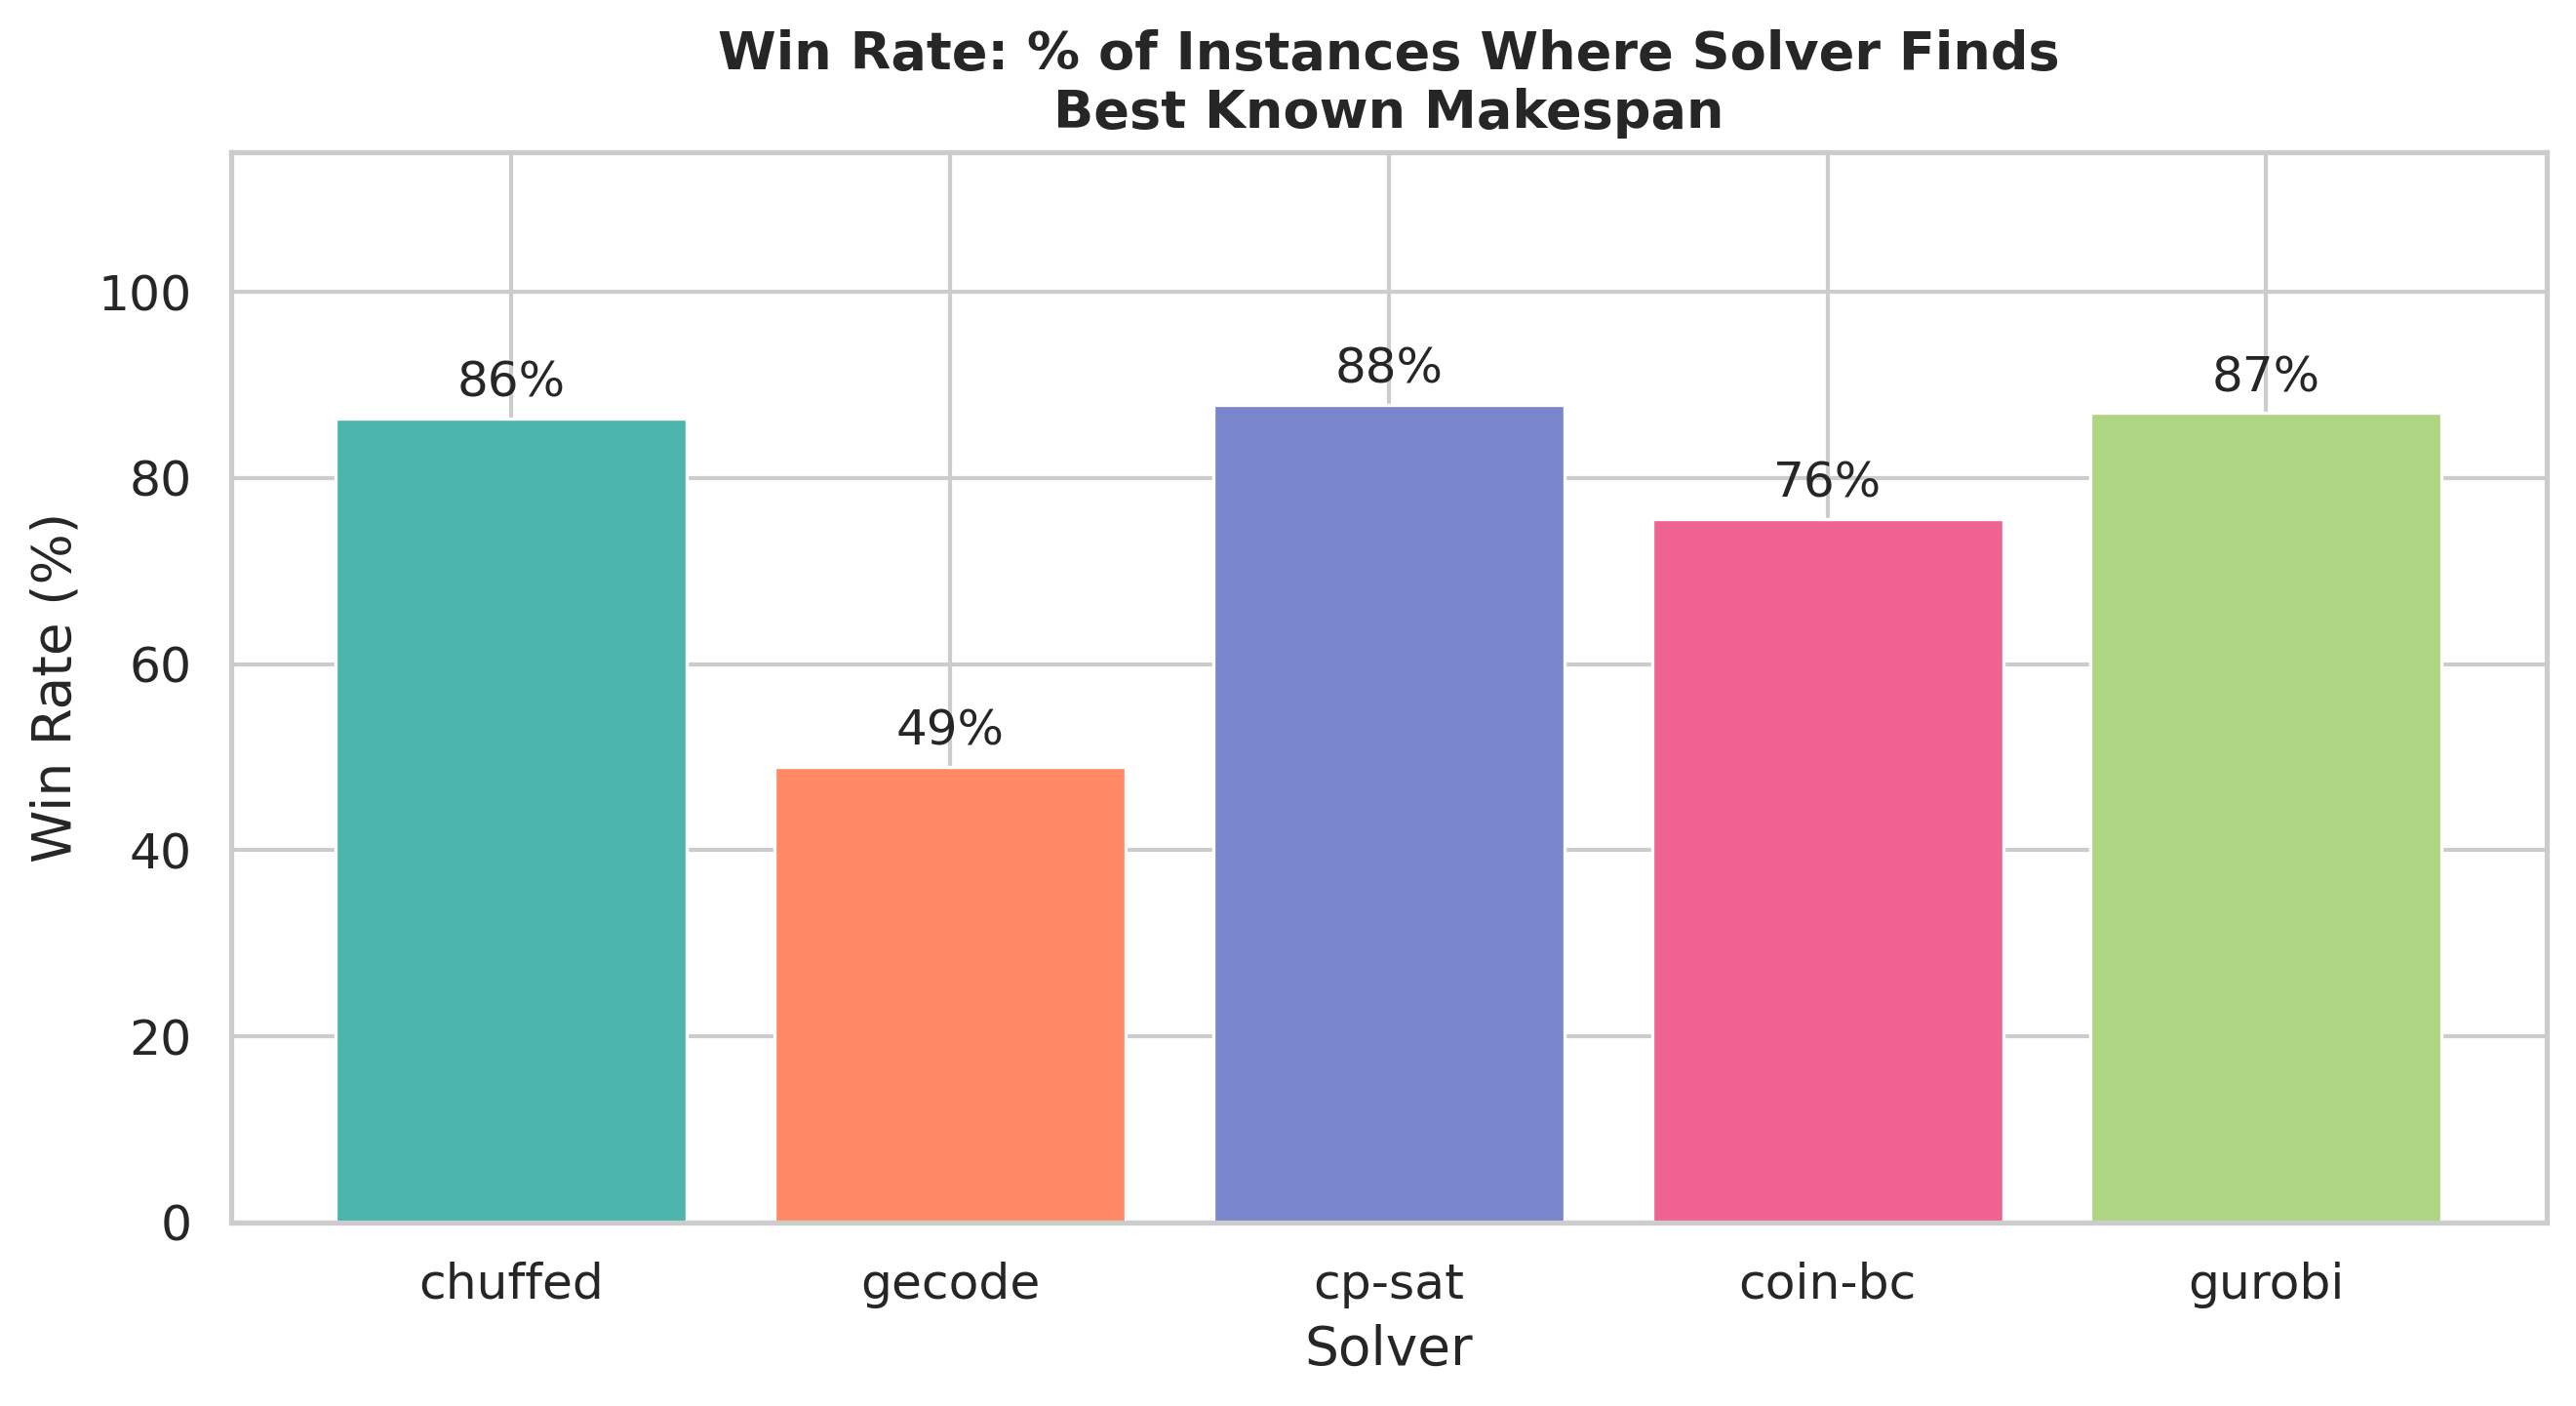

Plot 04b done.


In [22]:
# =============================================================================
# PLOT 4a — Solution Quality: Optimality Gap per Solver
# =============================================================================


def plot_optimality_gap(df):
    solved_df = df[df["solved"] & df["optimality_gap_pct"].notna()]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(
        data=solved_df,
        x="solver",
        y="optimality_gap_pct",
        order=SOLVER_ORDER,
        palette=SOLVER_PALETTE,
        ax=ax,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.5},
    )
    ax.set_title(
        "Solution Quality: Optimality Gap vs Best Found\n"
        "(lower = better; 0% = best solution across all solvers)",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Solver")
    ax.set_ylabel("Makespan Gap Above Best Found (%)")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "04a_optimality_gap.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Plot 04a done.")


# =============================================================================
# PLOT 4b — Win Rate per Solver
# =============================================================================


def plot_win_rate(df):
    solved_df = df[df["solved"] & df["optimality_gap_pct"].notna()]

    win_rate = (
        solved_df.groupby("solver")
        .apply(lambda g: (g["optimality_gap_pct"] <= 0.01).mean() * 100)
        .reindex(SOLVER_ORDER)
        .reset_index(name="win_pct")
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(
        win_rate["solver"],
        win_rate["win_pct"],
        color=[SOLVER_PALETTE[s] for s in win_rate["solver"]],
        edgecolor="white",
        linewidth=0.8,
    )
    ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=12)
    ax.set_title(
        "Win Rate: % of Instances Where Solver Finds\nBest Known Makespan",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Solver")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 115)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "04b_win_rate.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Plot 04b done.")


plot_optimality_gap(df)
plot_win_rate(df)

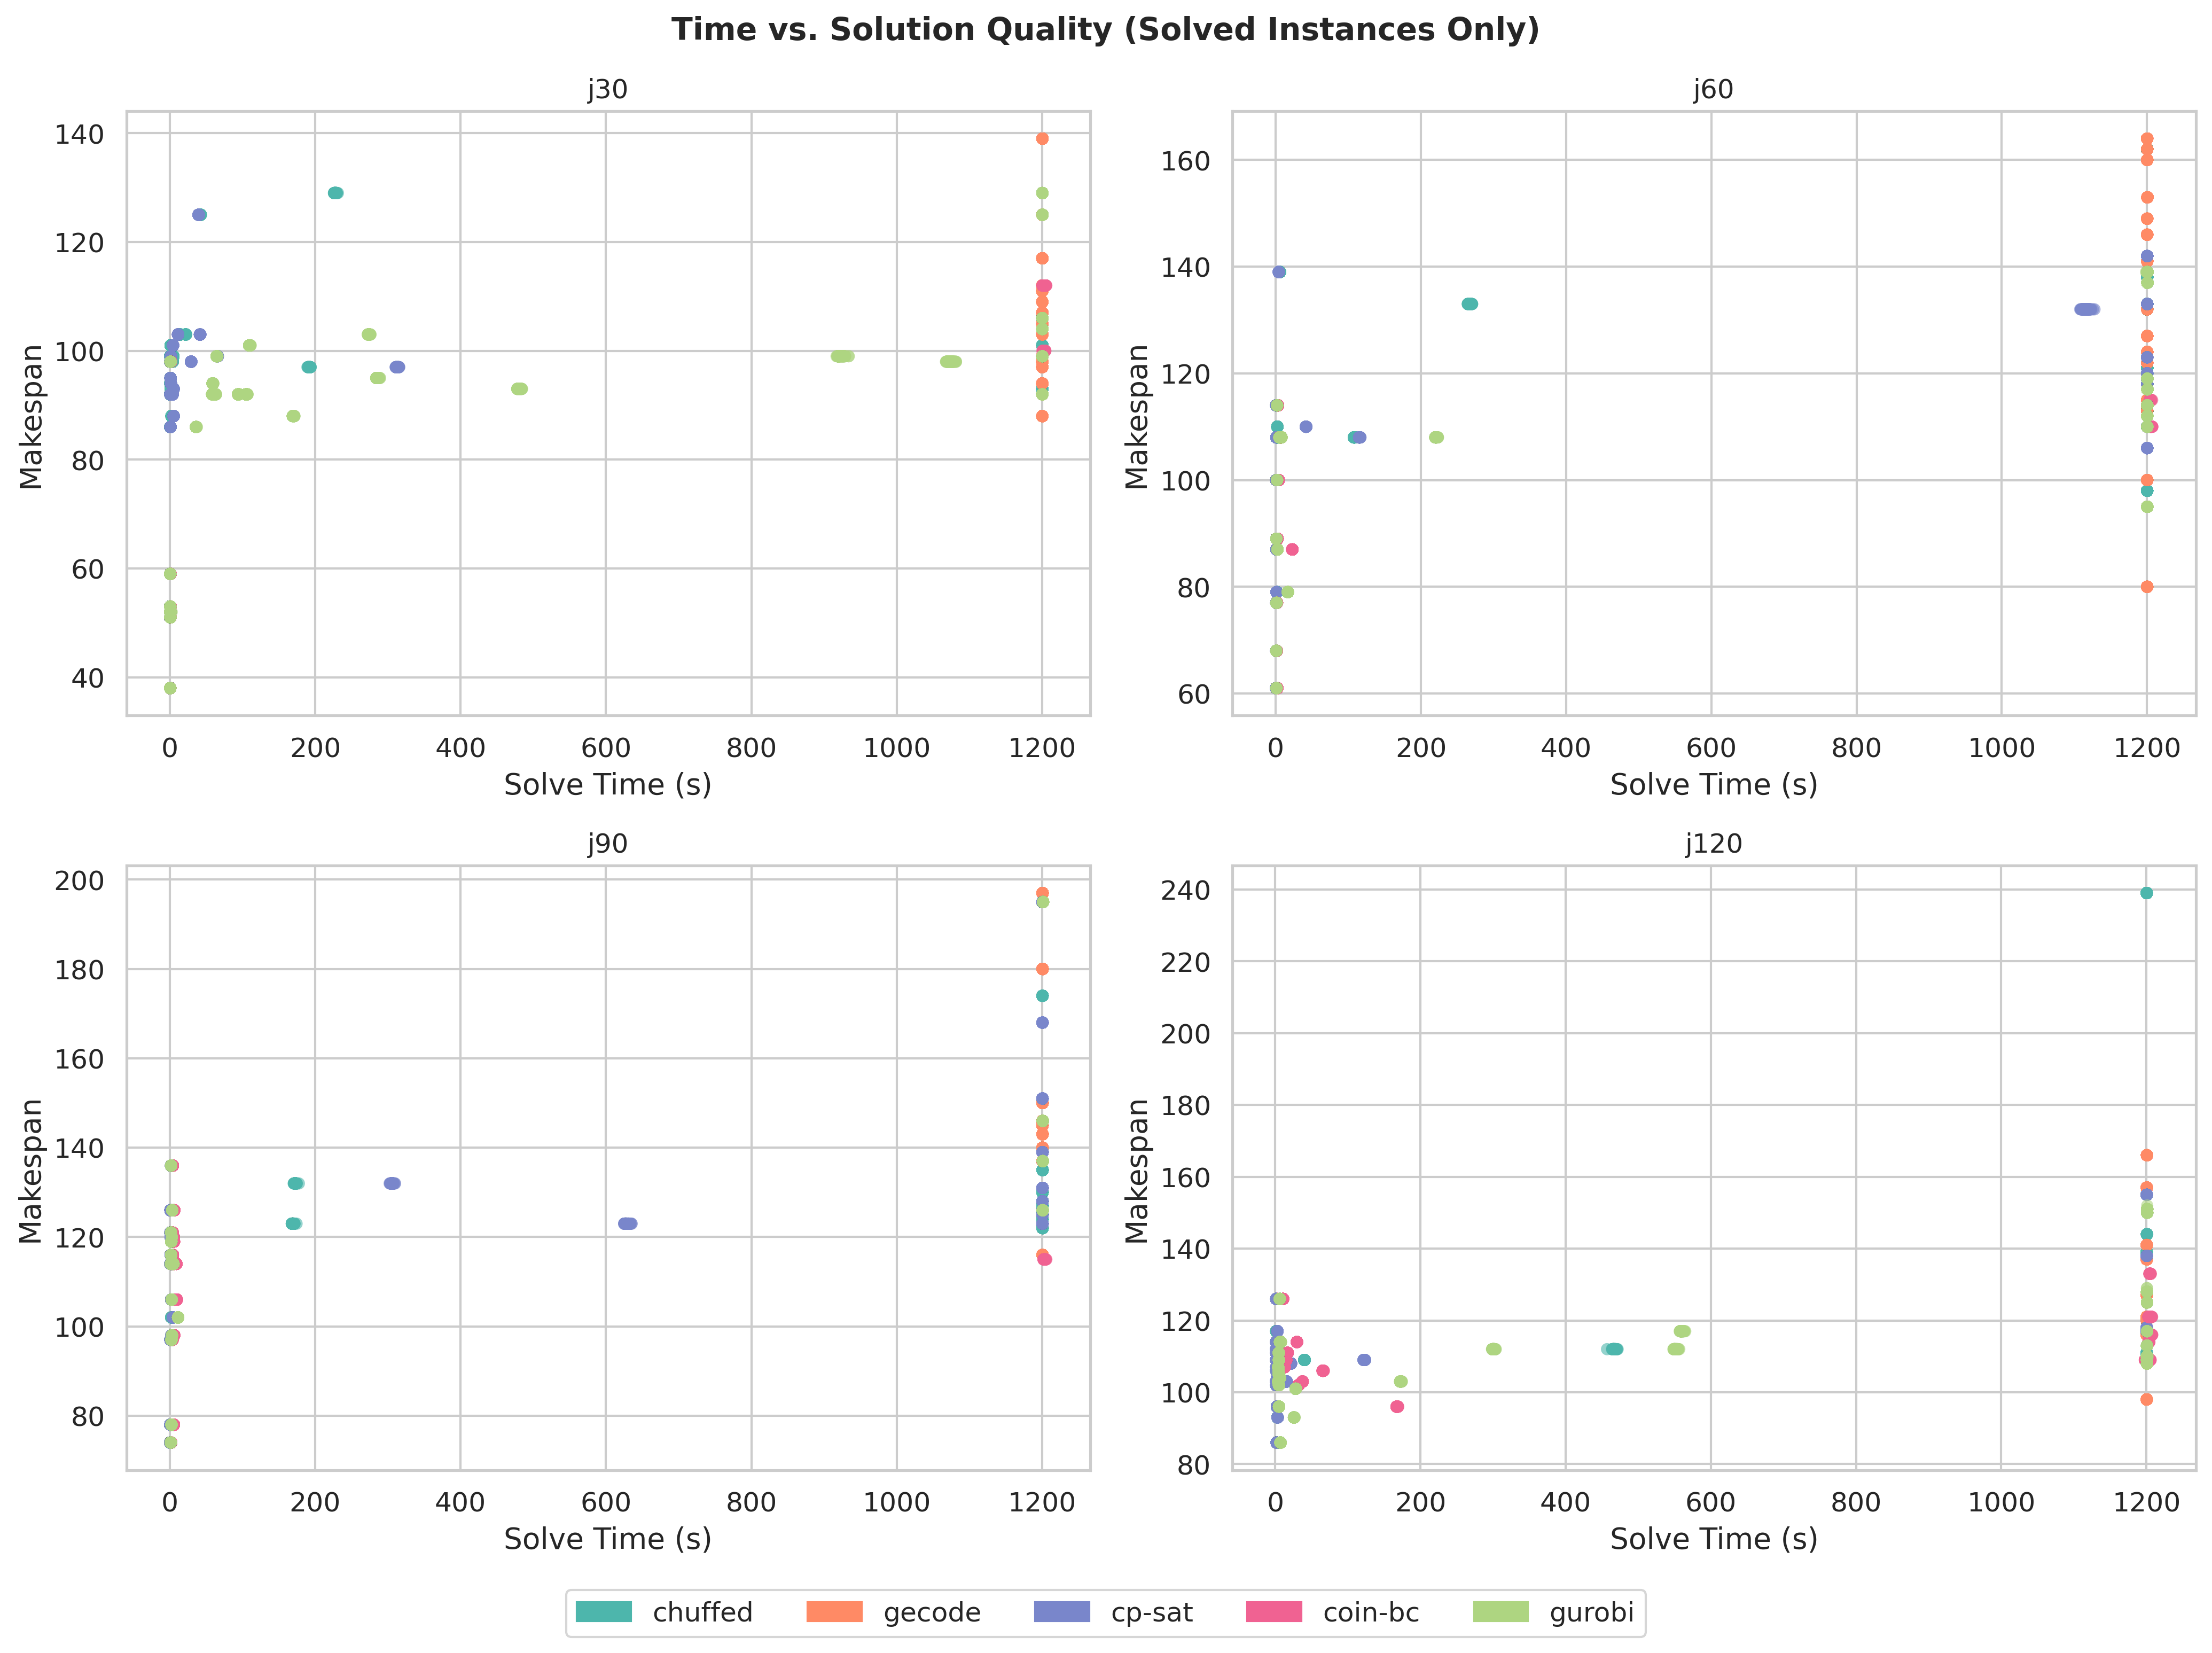

In [23]:
# =============================================================================
# PLOT 5 — Per-Solver Performance Profile
# =============================================================================
# For each problem size, show the joint distribution of solve time vs makespan.
# This reveals the time/quality trade-off per solver.
# =============================================================================


def plot_time_quality_scatter(df):
    solved = df[df["solved"]].copy()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, size in zip(axes, SIZE_ORDER):
        sub = solved[solved["problem_size"] == size]
        for solver in SOLVER_ORDER:
            s = sub[sub["solver"] == solver]
            if s.empty:
                continue
            ax.scatter(
                s["elapsed_seconds"],
                s["makespan"],
                color=SOLVER_PALETTE[solver],
                label=solver,
                alpha=0.6,
                s=30,
                edgecolors="none",
            )

        ax.set_title(size, fontsize=12)
        ax.set_xlabel("Solve Time (s)")
        ax.set_ylabel("Makespan")

    handles = [mpatches.Patch(color=SOLVER_PALETTE[s], label=s) for s in SOLVER_ORDER]
    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=5,
        bbox_to_anchor=(0.5, -0.04),
        frameon=True,
    )
    fig.suptitle(
        "Time vs. Solution Quality (Solved Instances Only)",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / "05_time_vs_quality.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_time_quality_scatter(df)

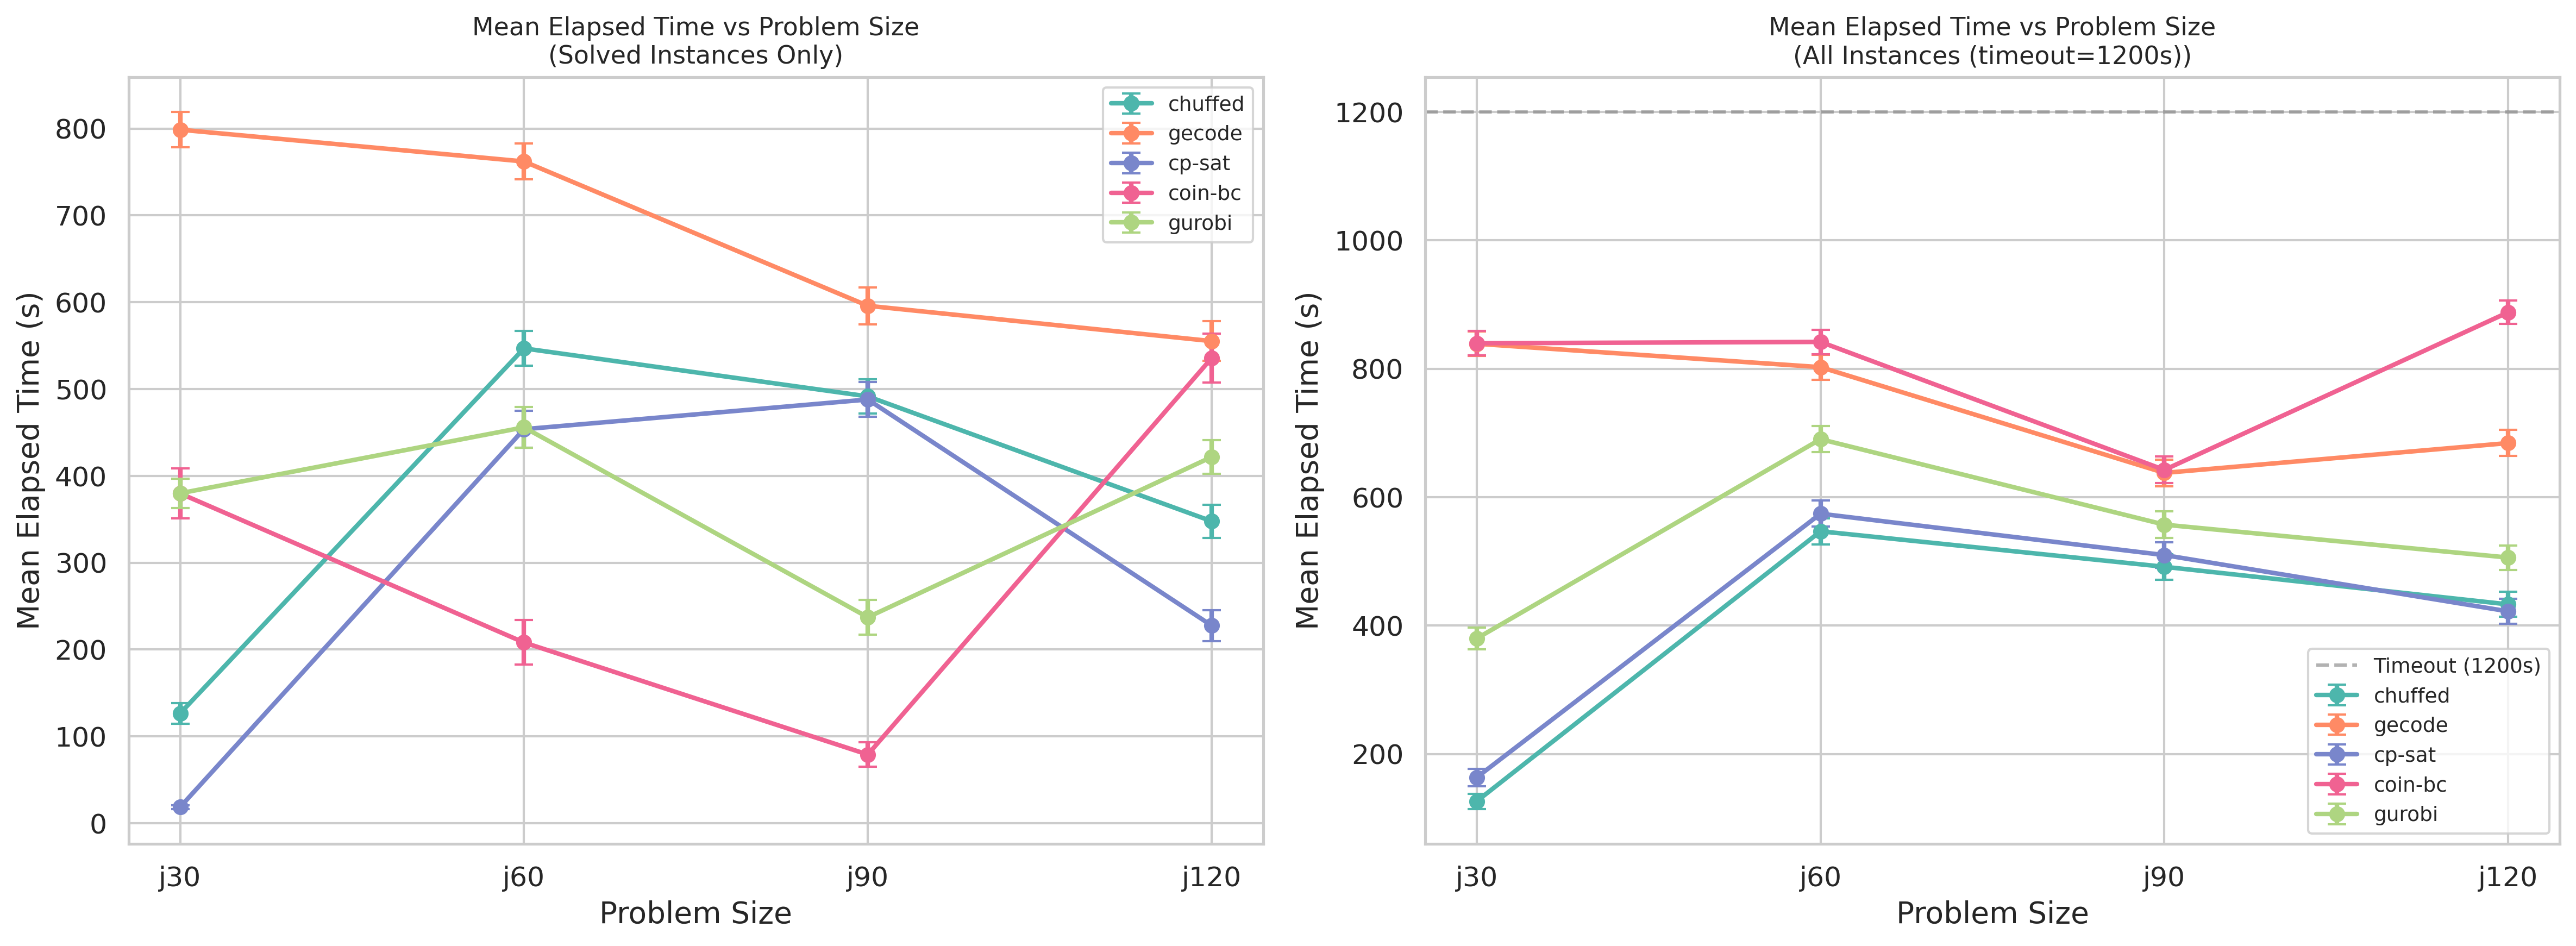

In [24]:
# =============================================================================
# PLOT 6 — Mean Elapsed Time vs Problem Size
# =============================================================================
# Separate lines for "solved instances only" vs "all" (incl. timeouts).
# =============================================================================


def plot_time_vs_size_fixed(df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, subset_label, mask in [
        (axes[0], "Solved Instances Only", df["solved"]),
        (axes[1], "All Instances (timeout=1200s)", pd.Series(True, index=df.index)),
    ]:
        sub = df[mask]
        stats_df = (
            sub.groupby(["problem_size", "solver"])["elapsed_seconds"]
            .agg(["mean", "sem"])
            .reset_index()
        )

        for solver in SOLVER_ORDER:
            s = stats_df[stats_df["solver"] == solver].sort_values("problem_size")
            if s.empty:
                continue
            sizes = s["problem_size"].astype(str)
            ax.errorbar(
                sizes,
                s["mean"],
                yerr=1.96 * s["sem"],
                label=solver,
                color=SOLVER_PALETTE[solver],
                marker="o",
                linewidth=2,
                capsize=4,
            )

        ax.set_title(
            f"Mean Elapsed Time vs Problem Size\n({subset_label})", fontsize=11
        )
        ax.set_xlabel("Problem Size")
        ax.set_ylabel("Mean Elapsed Time (s)")
        if mask.all():
            ax.axhline(
                TIMEOUT,
                color="gray",
                linestyle="--",
                alpha=0.6,
                linewidth=1.5,
                label=f"Timeout ({TIMEOUT}s)",
            )
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "06_time_vs_size_fixed.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_time_vs_size_fixed(df)

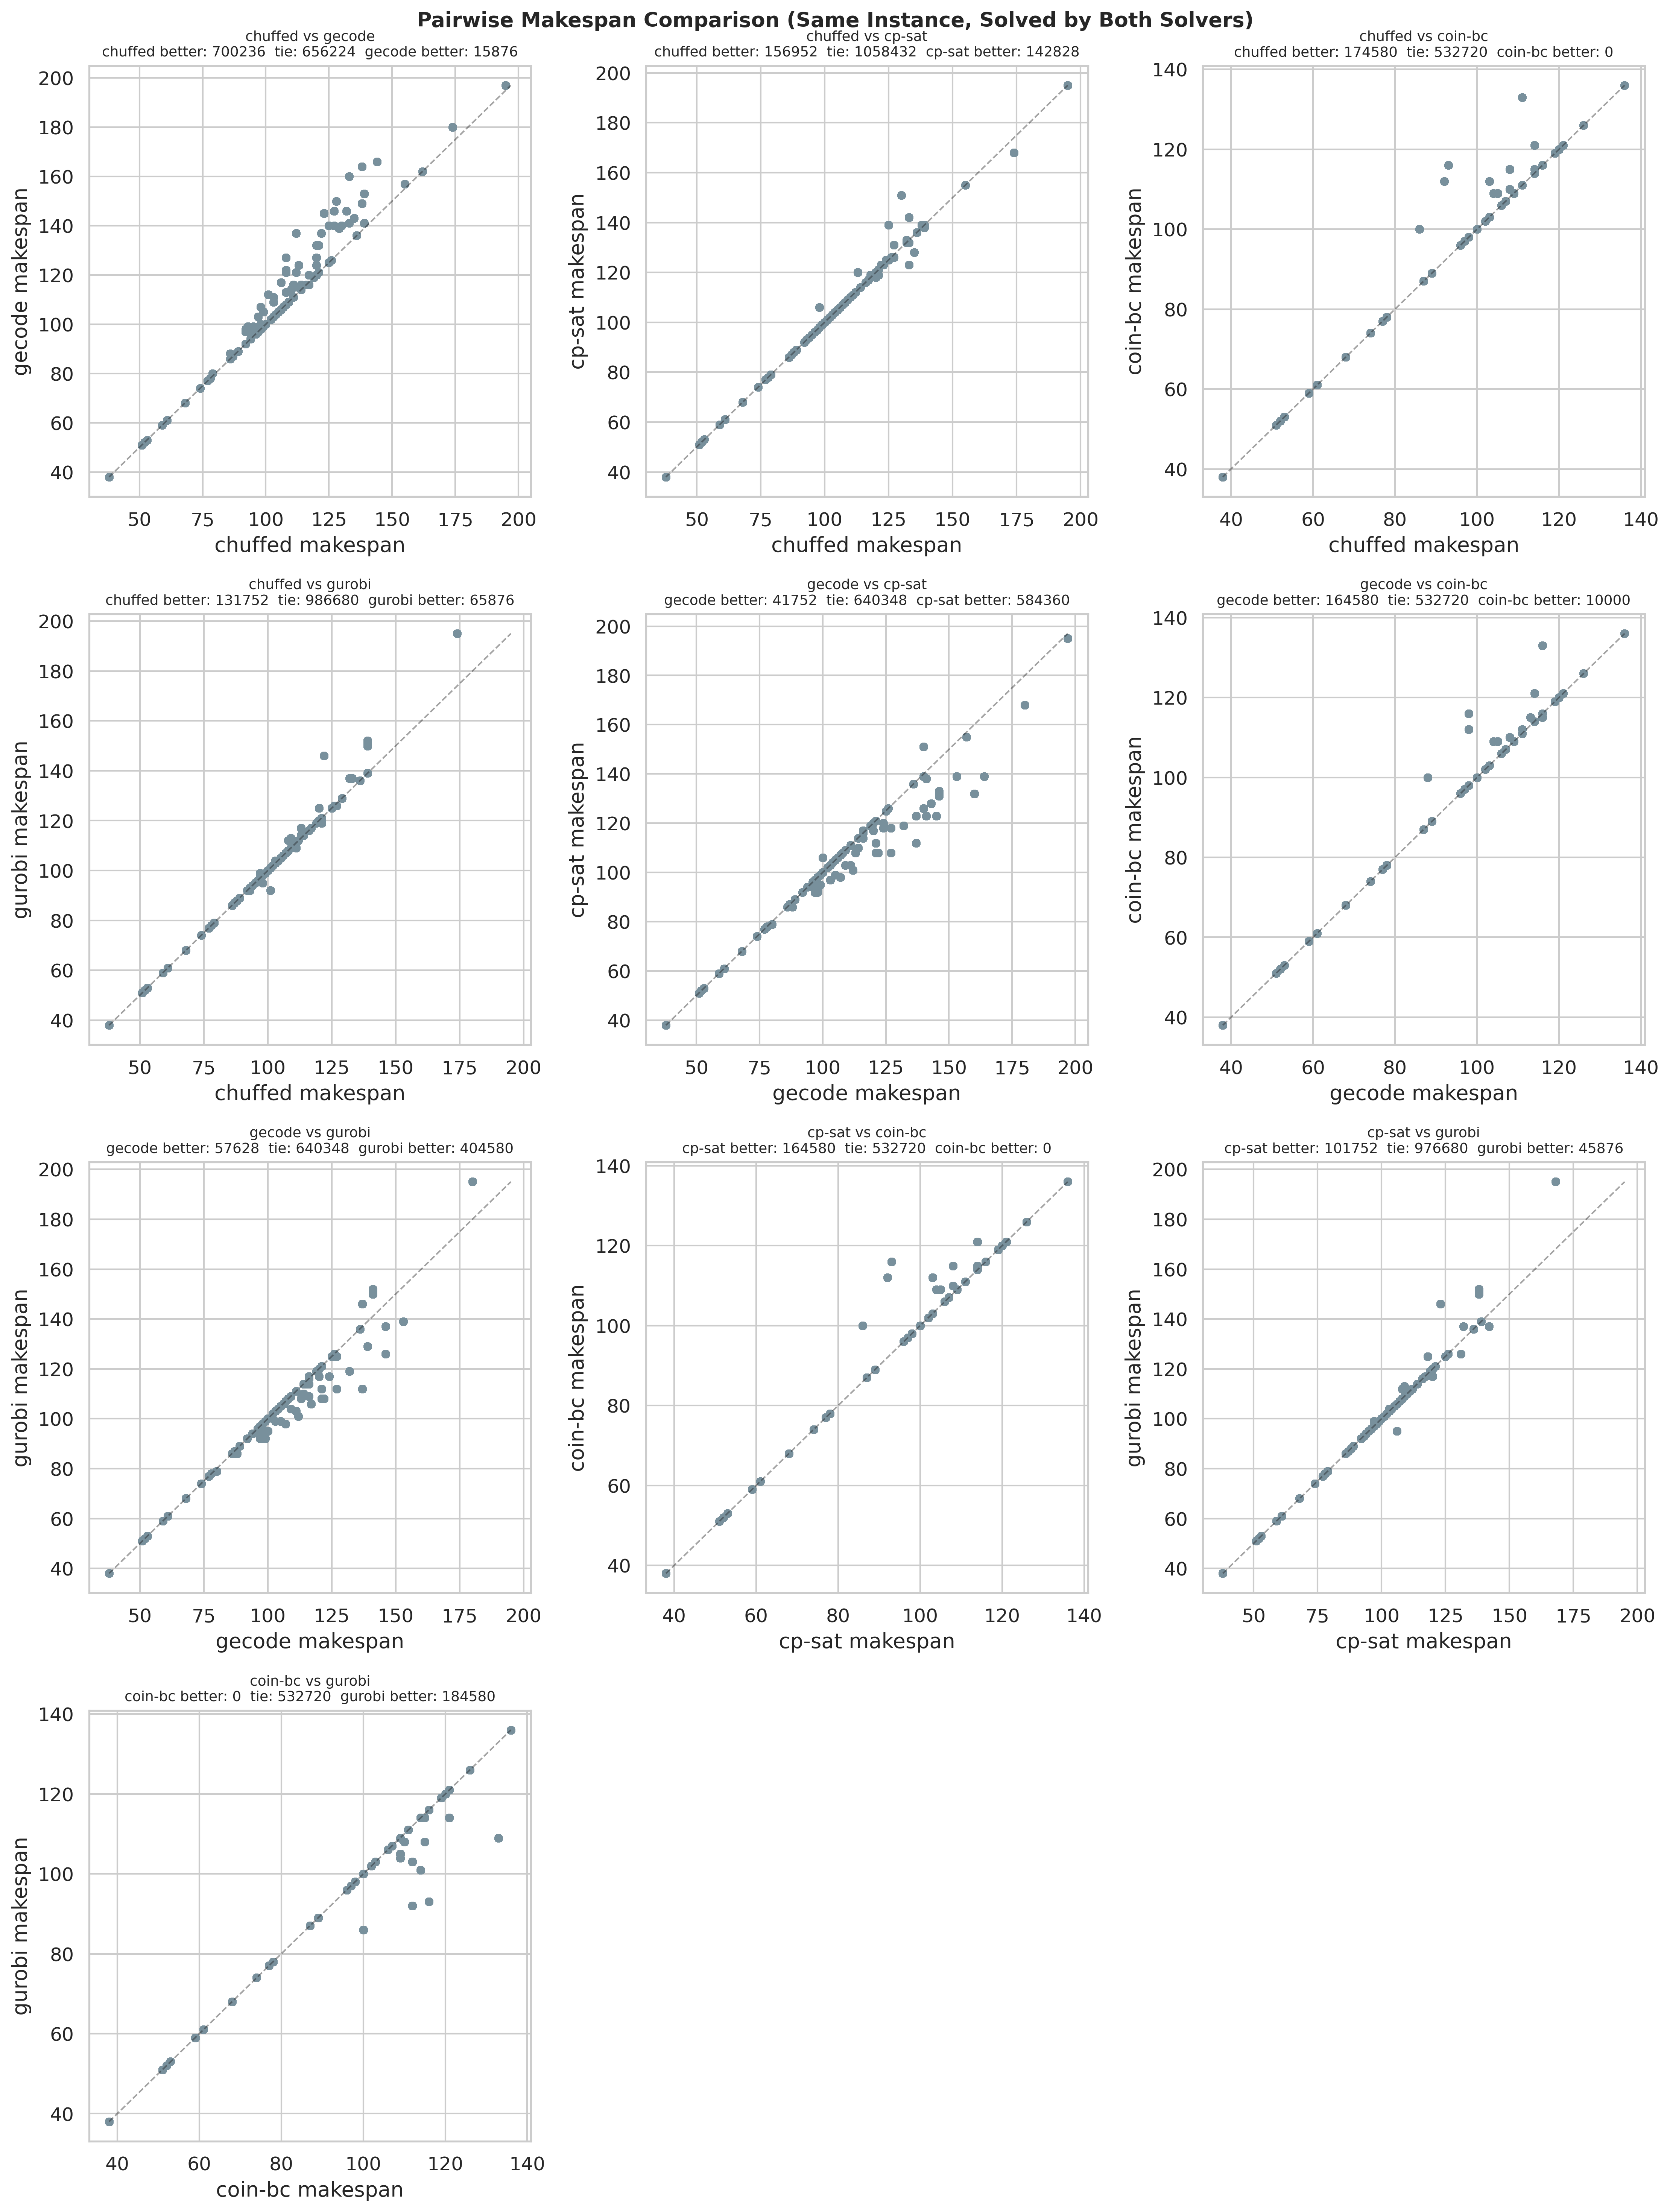

In [25]:
# =============================================================================
# PLOT 7 — Pairwise Solver Comparison
# =============================================================================
# For every pair of solvers, on the same instance, compare makespan.
# Shows dominance: is solver A always better, or does it depend on instance?
# =============================================================================


def plot_pairwise_comparison(df):
    pairs = list(combinations(SOLVER_ORDER, 2))
    n = len(pairs)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = axes.flatten()

    solved_df = df[df["solved"]][
        ["problem_size", "instance_name", "solver", "makespan"]
    ]

    for ax, (s1, s2) in zip(axes, pairs):
        d1 = solved_df[solved_df["solver"] == s1].rename(columns={"makespan": "m1"})
        d2 = solved_df[solved_df["solver"] == s2].rename(columns={"makespan": "m2"})
        merged = d1.merge(d2, on=["problem_size", "instance_name"])
        if merged.empty:
            ax.set_visible(False)
            continue

        ax.scatter(merged["m1"], merged["m2"], alpha=0.5, s=20, color="#78909c")
        lims = [
            min(merged["m1"].min(), merged["m2"].min()),
            max(merged["m1"].max(), merged["m2"].max()),
        ]
        ax.plot(lims, lims, "k--", alpha=0.4, linewidth=1)

        n_s1_better = (merged["m1"] < merged["m2"]).sum()
        n_s2_better = (merged["m2"] < merged["m1"]).sum()
        n_tie = (merged["m1"] == merged["m2"]).sum()

        ax.set_title(
            f"{s1} vs {s2}\n"
            f"{s1} better: {n_s1_better}  tie: {n_tie}  {s2} better: {n_s2_better}",
            fontsize=9,
        )
        ax.set_xlabel(f"{s1} makespan")
        ax.set_ylabel(f"{s2} makespan")

    for ax in axes[len(pairs) :]:
        ax.set_visible(False)

    fig.suptitle(
        "Pairwise Makespan Comparison (Same Instance, Solved by Both Solvers)",
        fontsize=13,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / "07_pairwise_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_pairwise_comparison(df)

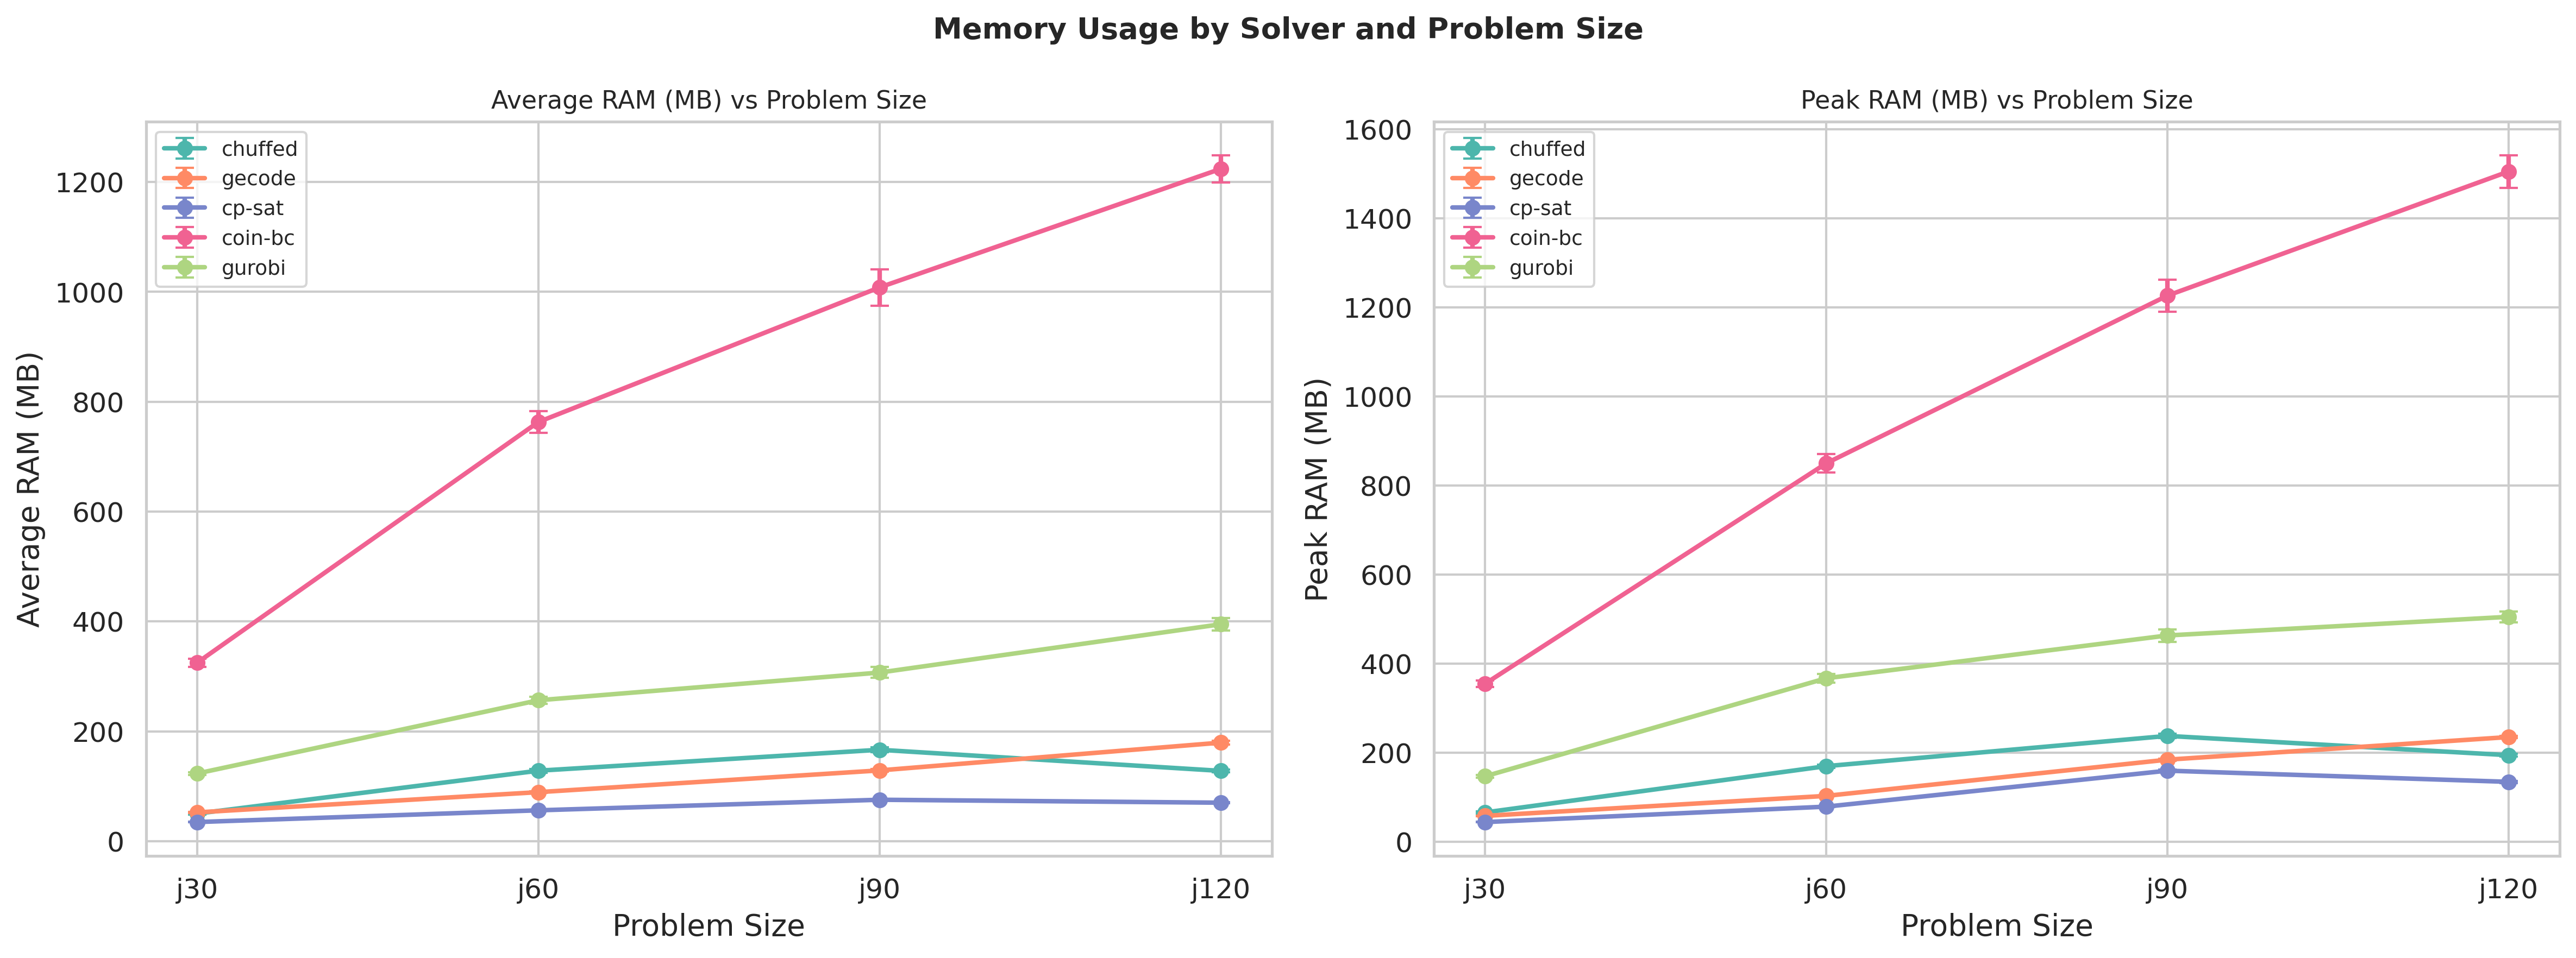

In [26]:
# =============================================================================
# PLOT 8 — Resource Usage: RAM vs Problem Size
# =============================================================================
# Instead of time vs. RAM (confounded by timeouts), show RAM by solver × size.
# This tells you about memory scaling, which is practically relevant.
# =============================================================================


def plot_ram_by_size(df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, col, label in [
        (axes[0], "avg_ram_mb", "Average RAM (MB)"),
        (axes[1], "max_ram_mb", "Peak RAM (MB)"),
    ]:
        stats_df = (
            df.groupby(["problem_size", "solver"])[col]
            .agg(["mean", "sem"])
            .reset_index()
        )
        for solver in SOLVER_ORDER:
            s = stats_df[stats_df["solver"] == solver].sort_values("problem_size")
            if s.empty:
                continue
            ax.errorbar(
                s["problem_size"].astype(str),
                s["mean"],
                yerr=1.96 * s["sem"],
                label=solver,
                color=SOLVER_PALETTE[solver],
                marker="o",
                linewidth=2,
                capsize=4,
            )
        ax.set_title(f"{label} vs Problem Size", fontsize=11)
        ax.set_xlabel("Problem Size")
        ax.set_ylabel(label)
        ax.legend(fontsize=9)

    fig.suptitle(
        "Memory Usage by Solver and Problem Size", fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(OUT_DIR / "08_ram_by_size.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_ram_by_size(df)

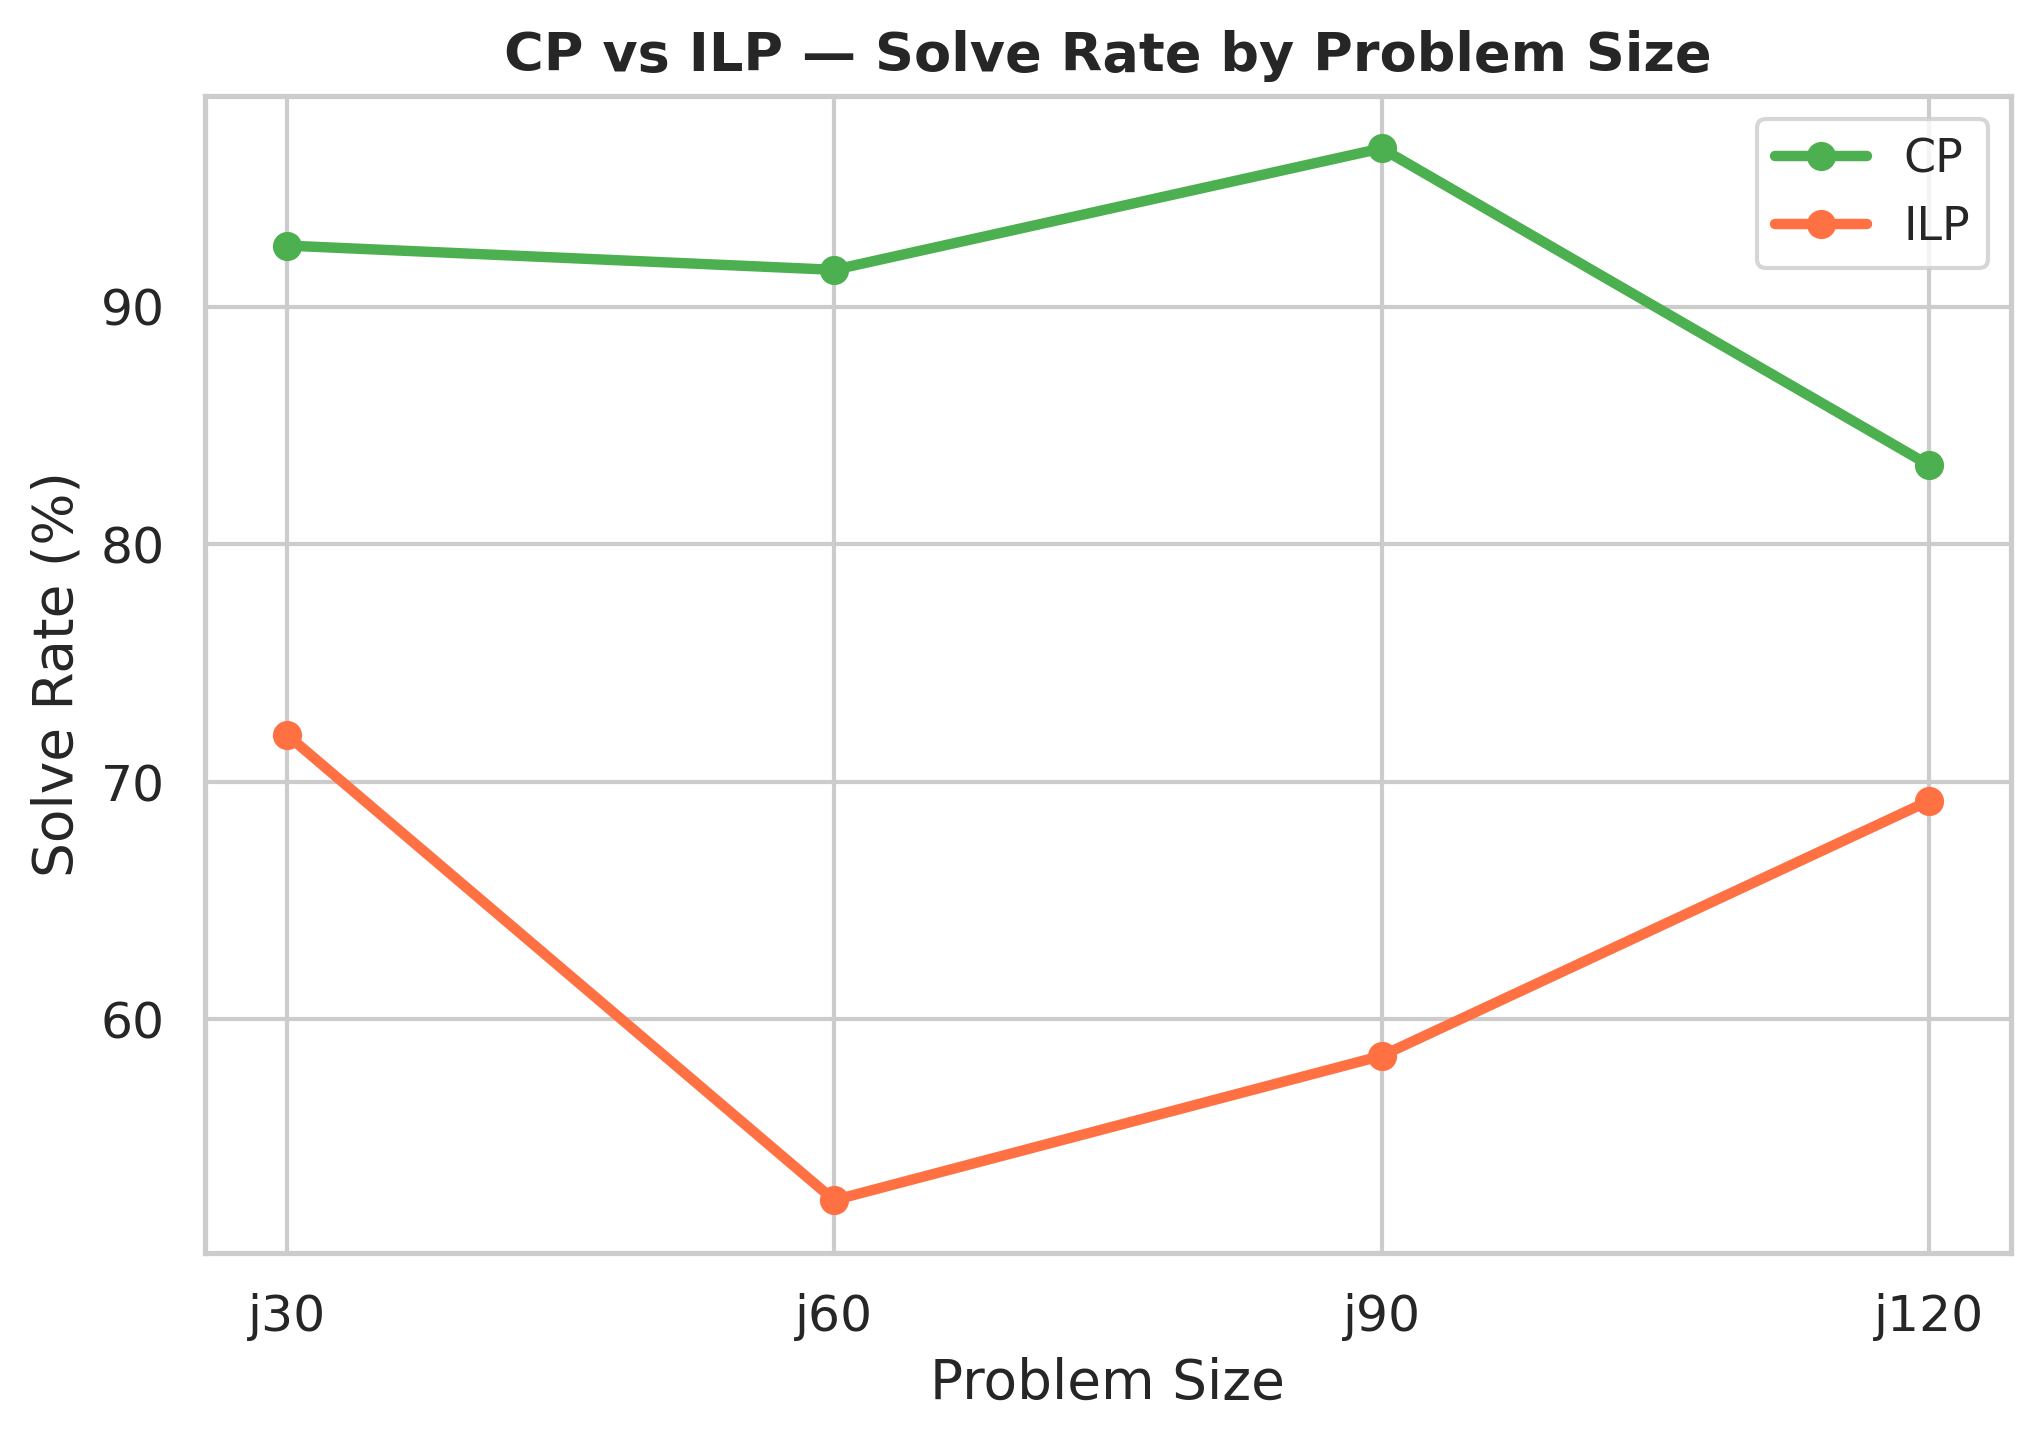

Plot 09a done.


/tmp/ipykernel_77313/2807569456.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


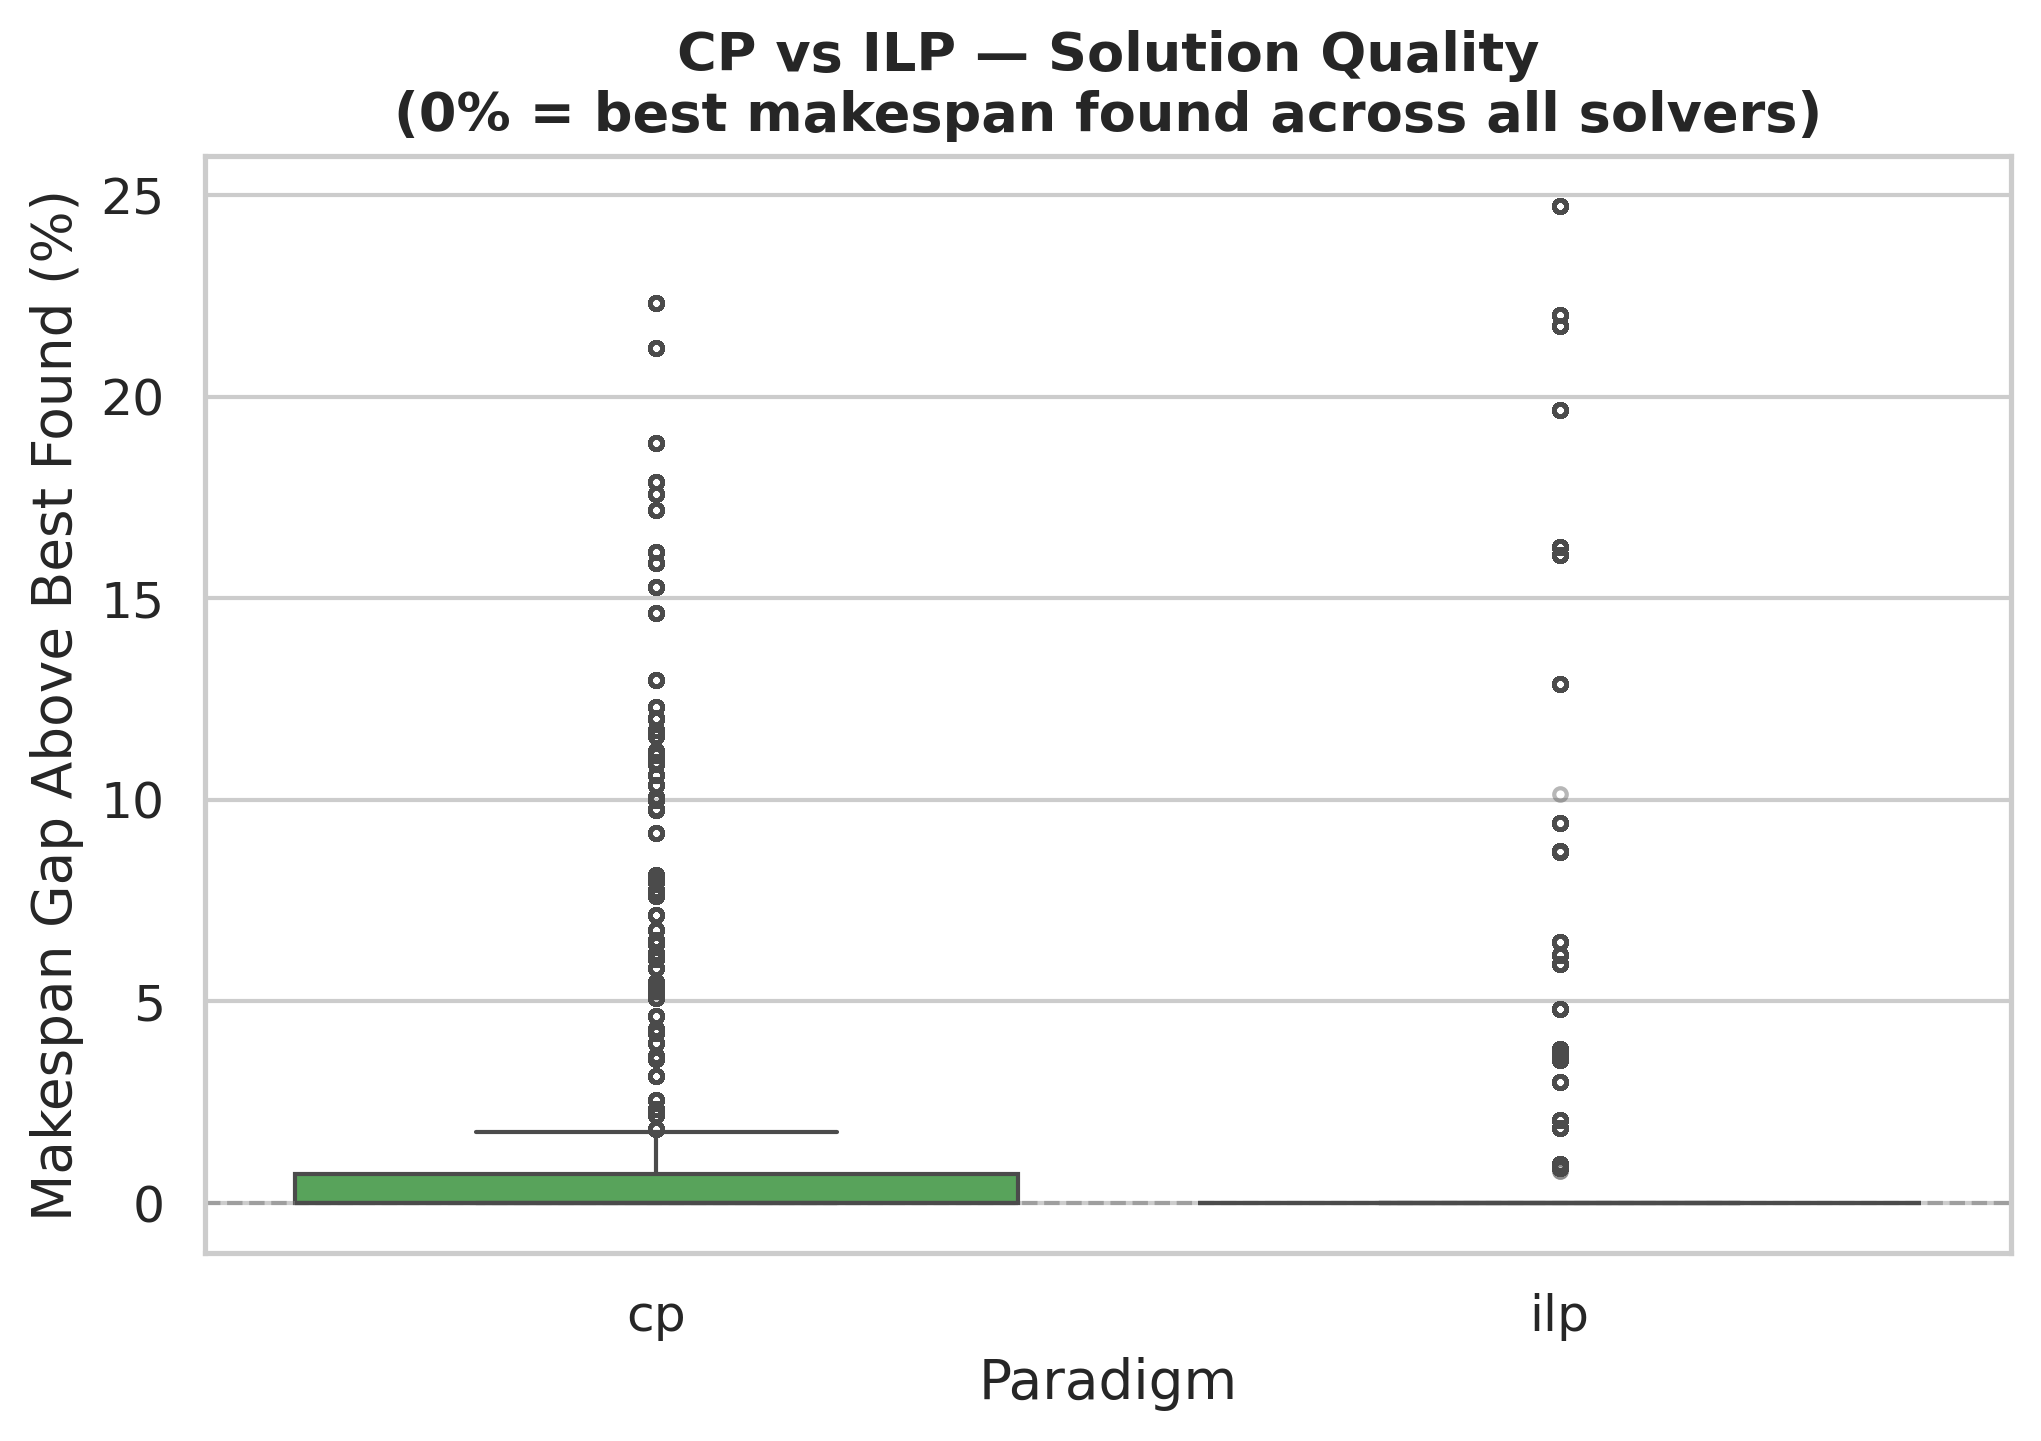

Plot 09b done.


In [27]:
# =============================================================================
# PLOT 9a — CP vs ILP: Solve Rate by Problem Size
# =============================================================================


def plot_paradigm_solve_rate(df):
    fig, ax = plt.subplots(figsize=(7, 5))

    pivot = (
        df.groupby(["paradigm", "problem_size"])["solved"].mean().mul(100).reset_index()
    )
    for paradigm, color in PARADIGM_COLOR.items():
        p = pivot[pivot["paradigm"] == paradigm].sort_values("problem_size")
        ax.plot(
            p["problem_size"].astype(str),
            p["solved"],
            marker="o",
            label=paradigm.upper(),
            color=color,
            linewidth=2.5,
        )

    ax.set_title(
        "CP vs ILP — Solve Rate by Problem Size", fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Problem Size")
    ax.set_ylabel("Solve Rate (%)")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "09a_paradigm_solve_rate.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Plot 09a done.")


# =============================================================================
# PLOT 9b — CP vs ILP: Solution Quality (makespan gap)
# =============================================================================


def plot_paradigm_quality(df):
    solved_df = df[df["solved"] & df["optimality_gap_pct"].notna()]

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(
        data=solved_df,
        x="paradigm",
        y="optimality_gap_pct",
        palette=PARADIGM_COLOR,
        ax=ax,
        order=["cp", "ilp"],
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )
    ax.set_title(
        "CP vs ILP — Solution Quality\n(0% = best makespan found across all solvers)",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Paradigm")
    ax.set_ylabel("Makespan Gap Above Best Found (%)")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "09b_paradigm_quality.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Plot 09b done.")


plot_paradigm_solve_rate(df)
plot_paradigm_quality(df)

In [28]:
# =============================================================================
# PLOT 10 — Summary Table
# =============================================================================


def print_summary_table(df):
    summary = (
        df.groupby("solver")
        .agg(
            n_runs=("elapsed_seconds", "count"),
            solve_rate_pct=("solved", lambda x: x.mean() * 100),
            mean_time_solved=(
                "elapsed_seconds",
                lambda x: x[df.loc[x.index, "solved"]].mean(),
            ),
            median_makespan=(
                "makespan",
                lambda x: x[df.loc[x.index, "solved"]].median(),
            ),
            avg_ram_mb=("avg_ram_mb", "mean"),
            peak_ram_mb=("max_ram_mb", "max"),
        )
        .round(1)
    )

    print("\n" + "=" * 80)
    print("SOLVER SUMMARY")
    print("=" * 80)
    print(summary.to_string())
    print("=" * 80 + "\n")

    # Non-parametric test: Kruskal-Wallis on makespan (solved instances only)
    groups = [
        df[(df["solver"] == s) & df["solved"]]["makespan"].dropna()
        for s in SOLVER_ORDER
    ]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = stats.kruskal(*groups)
        print(
            f"Kruskal-Wallis test on makespan (solved instances): H={stat:.2f}, p={p:.4f}"
        )
        if p < 0.05:
            print(
                "→ Significant differences in solution quality between solvers (p < 0.05)"
            )
        else:
            print("→ No significant difference in solution quality (p ≥ 0.05)")

    # Wilcoxon pairwise for solve time
    print("\nPairwise Mann-Whitney U on elapsed time (all instances):")
    for s1, s2 in combinations(SOLVER_ORDER, 2):
        t1 = df[df["solver"] == s1]["elapsed_seconds"]
        t2 = df[df["solver"] == s2]["elapsed_seconds"]
        if len(t1) < 3 or len(t2) < 3:
            continue
        stat, p = stats.mannwhitneyu(t1, t2, alternative="two-sided")
        sig = "**" if p < 0.01 else ("*" if p < 0.05 else "ns")
        print(f"  {s1:10} vs {s2:10}: p={p:.4f} {sig}")


print_summary_table(df)

print(f"\nAll plots saved to: {OUT_DIR.resolve()}")


SOLVER SUMMARY
         n_runs  solve_rate_pct  mean_time_solved  median_makespan  avg_ram_mb  peak_ram_mb
solver                                                                                     
chuffed   13040            97.5             379.0            108.0       118.2        451.0
gecode    13040            88.5             681.0            113.0       112.4        465.7
cp-sat    13040            87.1             301.8            107.0        59.1        401.6
coin-bc   13040            44.9             304.1            106.0       830.0       5242.4
gurobi    13040            81.2             378.1            103.0       270.4       1671.9

Kruskal-Wallis test on makespan (solved instances): H=1372.20, p=0.0000
→ Significant differences in solution quality between solvers (p < 0.05)

Pairwise Mann-Whitney U on elapsed time (all instances):
  chuffed    vs gecode    : p=0.0000 **
  chuffed    vs cp-sat    : p=0.0000 **
  chuffed    vs coin-bc   : p=0.0000 **
  chuffed    vs 